# QGSS 2026 Lab 2 — Noise, Backends, and Benchmarking in Qiskit

Welcome to Lab 2.

In this session, we connect the circuit model from earlier labs to **real quantum hardware**.
A quantum circuit is still the logical description of the computation, but the way it is executed depends on calibrated backend information such as native gates, connectivity, gate fidelities, readout performance, and coherence times.

The goal of this lab is to treat those hardware details as practical engineering information.
They help us choose layouts, build backend-informed simulators, and compare how different architectures affect transpiled circuits and measurement outcomes.

By the end of this notebook, you should be able to answer four practical questions:

1. **How do hardware noise and circuit size affect measured results?**
2. **What information does a backend contain?**
3. **How can we simulate backend-informed noise in Qiskit?**
4. **How can we compare different backends in a simple, quantitative way?**

## Table of Contents

- [Installation](#installation)
- [Imports](#imports)
- [Helper functions](#helper-functions)
- [Shared setup for the notebook](#shared-setup-for-the-notebook)
- [Chapter 1 — Noise in quantum computers and backend-aware simulation](#chapter-1--noise-in-quantum-computers-and-backend-aware-simulation)
  - [1.1 Looking at backend information](#11-looking-at-backend-information)
  - [1.2 What information defines a backend?](#12-what-information-defines-a-backend)
  - [1.3 First experiment: ideal versus noisy GHZ](#13-first-experiment-ideal-versus-noisy-ghz)
  - [1.4 Create a simple noisy simulator](#14-create-a-simple-noisy-simulator)
- [Chapter 2 — What kind of noise do we care about?](#chapter-2--what-kind-of-noise-do-we-care-about)
  - [2.1 Depolarization error](#21-depolarization-error)
  - [2.2 Pauli error](#22-pauli-error)
  - [2.3 Thermal relaxation](#23-thermal-relaxation)
  - [2.4 Quick summary of the three toy models](#24-quick-summary-of-the-three-toy-models)
- [Chapter 3 — Comparing Heron and Nighthawk Architectures](#chapter-3--comparing-heron-and-nighthawk-architectures)
  - [3.1 Layout Comparison](#31-layout-comparison)
  - [3.2 Benchmarking the Previous IBM QPUs](#32-benchmarking-the-previous-ibm-qpus)
- [Chapter 4 — Dynamic Circuit](#chapter-4--dynamic-circuit)
  - [4.1 Dynamic GHZ](#41-dynamic-ghz)
- [Bonus](#bonus)
- [Wrap-up](#wrap-up)

## Installation

If you are running this notebook in a fresh environment, uncomment and run the next cell.

In [1]:
!pip install -q qiskit==2.4.0rc2 qiskit-aer qiskit-ibm-runtime==0.47.0 qiskit_experiments pandas matplotlib pylatexenc seaborn sympy  
!pip install --upgrade git+https://github.com/qiskit-community/Quantum-Challenge-Grader.git

  Cloning https://github.com/qiskit-community/Quantum-Challenge-Grader.git to /tmp/pip-req-build-94m9xxvn
  Running command git clone --filter=blob:none --quiet https://github.com/qiskit-community/Quantum-Challenge-Grader.git /tmp/pip-req-build-94m9xxvn
  Resolved https://github.com/qiskit-community/Quantum-Challenge-Grader.git to commit 2ae3338286eb0f0d505b311f936a7961dbd0f646
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached moocore-0.3.2-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (6.5 kB)
  Using cached typeguard-4.5.2-py3-none-any.whl.metadata (3.8 kB)
Using cached moocore-0.3.2-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (879 kB)
Using cached typeguard-4.5.2-py3-none-any.whl (36 kB)
  Created wheel for qc_grader: filename=qc_grader-2026.7.16-py3-none-any.whl size=54327 sha256=d0914caa30be26e2d1831e45ac

## Imports

In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

from IPython.display import display

from qiskit import QuantumCircuit, transpile, generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit.providers.exceptions import QiskitBackendNotFoundError
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeNighthawk, FakeTorino
from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2
from qiskit.visualization import plot_gate_map

from qc_grader.challenges.qgss_2026 import check_progress
from qc_grader.challenges.qgss_2026.lab2 import (
    grade_lab2_ex1,
    grade_lab2_ex2,
    grade_lab2_ex3,
    grade_lab2_ex4,
    grade_lab2_ex5,
    grade_lab2_ex6,
    grade_lab2_ex7,
)

## Helper functions

We use a few small helper functions to keep the main experiments readable.

In [3]:
def run_counts(backend, circuit, shots=4096):
    sampler = Sampler(mode=backend)
    job = sampler.run([circuit], shots=shots)
    result = job.result()
    cr = list(result[0].data.keys())
    if len(cr) != 1:
        raise ValueError(f"Expected exactly one circuit result, got {len(cr)}")
    counts = result[0].data[cr[0]].get_counts()
    return counts

def transpile_and_run_counts(backend, circuit, shots=4096):
    tqc = transpile(circuit, backend)
    return run_counts(backend, tqc, shots)

def prob_of_zero(counts, nbits=1):
    key = "0" * nbits
    return counts.get(key, 0) / sum(counts.values())

def backend_summary(backend, max_rows=8, single_qubit_gates=None, two_qubit_gates=None):
    qubit_rows = []
    props = backend.properties()
    for q in range(min(backend.num_qubits, max_rows)):
        qubit_rows.append({
            "qubit": q,
            "T1 (us)": None if props is None else round(props.t1(q) * 1e6, 2),
            "T2 (us)": None if props is None else round(props.t2(q) * 1e6, 2),
            "readout_error": None if props is None else round(props.readout_error(q), 5),
        })
        if single_qubit_gates is not None and props is not None:
            for gate in single_qubit_gates:
                error = props.gate_error(gate, [q])
                if error is not None:
                    qubit_rows[-1][f"{gate} error"] = round(error, 5)

    coupling_rows = []
    if two_qubit_gates is not None and props is not None:
        for gate in two_qubit_gates:
            for pair in backend.configuration().coupling_map:
                error = props.gate_error(gate, pair)
                if error is not None:
                    coupling_rows.append({
                        "qubit1": pair[0],
                        "qubit2": pair[1],
                        f"{gate} error": round(error, 5)
                    })

    return pd.DataFrame(qubit_rows), pd.DataFrame(coupling_rows)


# Chapter 1 — Noise in quantum computers and backend-aware simulation

In the circuit model, the output of a circuit is determined by the operations we write down.
On quantum hardware, the measured result also depends on the **quality and structure of the backend**.

Once we connect a circuit to a backend, the device becomes part of the computational workflow.
Two logically equivalent circuits can behave differently if they are executed on different backends, or even on different qubits of the same backend.

There are three beginner-level ideas to keep in mind.

- **Gate errors:** every gate is imperfect, and two-qubit gates are usually noisier than one-qubit gates.
- **Decoherence:** qubits gradually lose quantum information over time, often characterized by $T_1$ and $T_2$.
- **Noise accumulation:** larger circuits are generally harder because they contain more gates and take more time.

Here, $T_1$ is the energy-relaxation time, which describes how quickly an excited qubit tends to relax toward $|0\rangle$. $T_2$ is the phase-coherence time, which describes how quickly relative phase information in a superposition decays.

To reason about these effects in practice, we need to read backend information and use that information in simulation.
In this chapter, we will first inspect what a backend tells us, and then use the same backend model in simple noisy experiments.

### 1.1 Looking at backend information

If you open [IBM Quantum Platform](https://quantum.cloud.ibm.com/computers) and inspect a real backend, you will typically see properties such as

- basis gates,
- coupling map (showing connectivity),
- CLOPS (circuit layer operations per second),
- one-qubit and two-qubit gate errors,
- readout errors,
- $T_1$ and $T_2$ values.

These properties give a first estimate of how to match a circuit to the backend.
For example, gate and readout errors provide useful information for choosing qubit layouts and transpilation strategies.
The $T_1$ and $T_2$ times provide characteristic relaxation and coherence timescales for selecting circuit depths and execution schedules that are well matched to the device.

This is often the first place to look before running a circuit.
You try to understand what kind of hardware you are dealing with before you decide how to transpile, on which qubits to place the circuit, and how much noise to expect.

### 1.2 What information defines a backend?

When we prepare to run a circuit on a backend, it is important to consider these questions:

- What gates does the device natively support?  
- Which qubits are directly connected?  
- How noisy are the available operations and measurements?

Together, these properties determine how the transpiler rewrites your circuit and how much error you should expect when it is executed.

In the next few cells, we inspect these ingredients one by loading a real IBM Quantum device `ibm_miami`.

In [4]:
# Paste your IBM Cloud credentials here. You only need to do this once per environment.
# After it works, you can comment these lines out so the credentials do not stay in the file.

token = "Jfoe5q8RyJgaTwtPtD4PsoXBL7OnazfH-_oRP7otxbEw"
instance = 'crn:v1:bluemix:public:quantum-computing:us-east:a/5a51d217d6944d5d8d0991895f00c4b4:901b4455-162a-48f3-9ec7-c6142fda7294::'


QiskitRuntimeService.save_account(
    token=token,
    instance=instance,
    overwrite=True,
    set_as_default=True,
)

In [5]:
service = QiskitRuntimeService()

try:
    print("Available backends:", service.backends())
    backend_miami = service.backend("ibm_fez")
except QiskitBackendNotFoundError as e:
    print(
        "Could not find 'ibm_miami' among the available Open Plan backends. "
        "The backend may be temporarily unavailable, under maintenance, or not accessible "
        "from the current account/region. Falling back to FakeNighthawk."
    )
    backend_miami = FakeNighthawk()
    

print("Backend:", backend_miami.name)
print("\nBasis operations:")
print(backend_miami.operation_names)
print("\nCoupling-map edges:")
print(backend_miami.coupling_map.get_edges())
#display(backend_miami.coupling_map.draw())

single_qubit_summary, two_qubit_summary = backend_summary(backend_miami, single_qubit_gates=["sx", "x"], two_qubit_gates=["cz"])

print("Qubit Properties: (8 qubits only)")
#display(single_qubit_summary)

print("\nTwo-Qubit Properties: (8 couplings only)")
#display(two_qubit_summary.head(8))

Available backends: [<IBMBackend('ibm_fez')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_kingston')>]
Backend: ibm_fez

Basis operations:
['x', 'sx', 'if_else', 'measure', 'id', 'cz', 'reset', 'delay', 'rz']

Coupling-map edges:
EdgeList[(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (3, 16), (4, 3), (4, 5), (5, 4), (5, 6), (6, 5), (6, 7), (7, 6), (7, 8), (7, 17), (8, 7), (8, 9), (9, 8), (9, 10), (10, 9), (10, 11), (11, 10), (11, 12), (11, 18), (12, 11), (12, 13), (13, 12), (13, 14), (14, 13), (14, 15), (15, 14), (15, 19), (16, 3), (16, 23), (17, 7), (17, 27), (18, 11), (18, 31), (19, 15), (19, 35), (20, 21), (21, 20), (21, 22), (21, 36), (22, 21), (22, 23), (23, 16), (23, 22), (23, 24), (24, 23), (24, 25), (25, 24), (25, 26), (25, 37), (26, 25), (26, 27), (27, 17), (27, 26), (27, 28), (28, 27), (28, 29), (29, 28), (29, 30), (29, 38), (30, 29), (30, 31), (31, 18), (31, 30), (31, 32), (32, 31), (32, 33), (33, 32), (33, 34), (33, 39), (34, 33), (34, 35), (35, 19), (35, 34),

As we learned in the previous lab, when a circuit is transpiled for a real backend, limited connectivity and basis operations introduce additional overheads to the resulting circuit:

- additional SWAP gates are required to entangle two qubits out of the connectivity,
- the gates should be decomposed into available ones.

Also, the table above shows that backend properties are not perfectly uniform across qubits. Gate errors, readout errors, and coherence times can vary from one qubit to another.

<div class="alert alert-block alert-success">
<b>Exercise 1.</b>
    Load 156-qubit Heron system <code>ibm_fez</code>, and submit its basis operations and coupling map.
</li>
    </ul>
</div>

In [6]:
backend_fez = service.backend("ibm_fez")

## TODO: Add your code here ##
# basis_operations =  # list[str]
# coupling_map =  # list[list[int] | tuple[int, int]] | EdgeList
basis_operations = backend_fez.operation_names
coupling_map = backend_fez.coupling_map.get_edges()

In [7]:
grade_lab2_ex1(basis_operations, coupling_map)

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. You have correctly identified the basis operations and coupling map. 

You scored 2 on this exercise.


### 1.3 Create a simple noisy simulator

There are two useful ways to simulate noisy backends in Qiskit.

The first approach is to construct a noisy simulator from backend information.

The backend can be either a fake backend or a real backend that is accessible from your IBM Quantum account. In both cases, `AerSimulator.from_backend(...)` uses backend information such as basis gates, coupling map, and calibration-based noise properties to build a simulator that reflects device-level characteristics.

This is convenient when we want to study how a circuit behaves under backend-informed noise while still running the experiment as a simulation.

The second is to build a **custom noise model** ourselves.
This is useful when we want a controlled experiment.
Instead of inheriting all device properties at once, we can choose a specific type of noise and adjust its strength directly.
This makes it easier to see how a single noise mechanism changes the outcome of a circuit.

In [8]:
# 1. Backend-informed noisy simulator
# This backend can be a fake backend or a real backend accessible from your account.
backend = service.backend("ibm_fez") # FakeTorino
backend_simulator = AerSimulator.from_backend(backend)


# 2. Custom noisy simulator defined directly by basis gates + connectivity + noise
basis_gates_single_noisy = ["sx", "x"]
basis_gates_single_ideal = ["rz", "measure"]
basis_gates_two_qubit = ["cx"]
basis_gates_custom = basis_gates_single_noisy + basis_gates_single_ideal + basis_gates_two_qubit

coupling_map_custom = [[0, 1], [1, 2], [2, 3], [3, 4]]
coupling_map_custom += [[1, 0], [2, 1], [3, 2], [4, 3]]  # add reverse directions for undirected connectivity

lam_1q = 0.003
lam_2q = 0.03
p_readout = 0.015

noise_model_custom = NoiseModel(basis_gates=basis_gates_custom)

# 1-qubit gate noise
err_1q = depolarizing_error(lam_1q, 1)
for gate in basis_gates_single_noisy:
    noise_model_custom.add_all_qubit_quantum_error(err_1q, gate)

# 2-qubit gate noise
err_2q = depolarizing_error(lam_2q, 2)
for gate in basis_gates_two_qubit:
    noise_model_custom.add_all_qubit_quantum_error(err_2q, gate)

# readout noise
readout_err = ReadoutError([
    [1 - p_readout, p_readout],
    [p_readout, 1 - p_readout],
])
noise_model_custom.add_all_qubit_readout_error(readout_err)

# Finally define the custom noisy simulator
sim_custom_backend = AerSimulator(
    noise_model=noise_model_custom,
    basis_gates=basis_gates_custom,
    coupling_map=coupling_map_custom,
)


### 1.4 First experiment: ideal versus noisy GHZ

In this first experiment, we follow the Qiskit pattern:

1. **Map** the problem to a quantum circuit by preparing a GHZ state.
2. **Optimize** the circuit for the backend or simulator using transpilation.
3. **Execute** the circuit on an ideal simulator and a backend-informed noisy simulator.
4. **Analyze** the output distributions and compare them with the ideal GHZ behavior.

To inspect how the noise affects the outcome, we now build a simple GHZ circuit and compare

- an ideal simulator,
- a fake-backend simulator with realistic hardware noise.

The GHZ circuit is a good first example because its ideal output is very simple. 
In the absence of noise, the probability should be concentrated on only two bitstrings: all zeros and all ones.


#### Qiskit pattern step 1: Map
We first map the experiment to a quantum circuit by preparing a 5-qubit GHZ state and measuring all qubits.

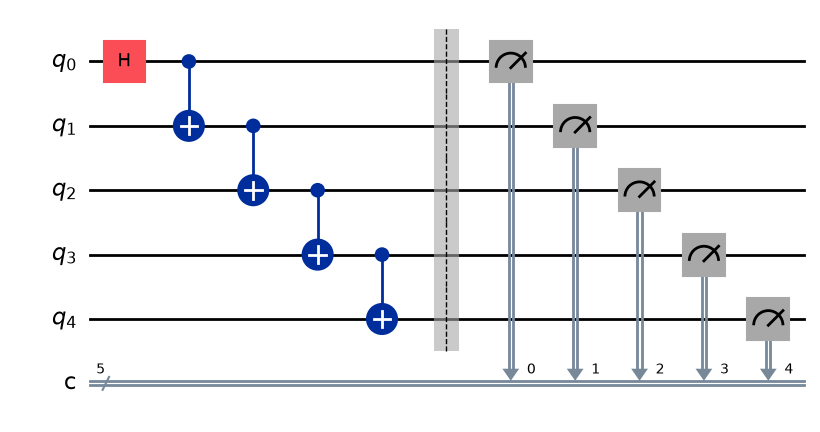

In [9]:
n = 5

qc_ghz = QuantumCircuit(n, n)
qc_ghz.h(0)
for i in range(n - 1):
    qc_ghz.cx(i, i + 1)
qc_ghz.barrier()
qc_ghz.measure(range(n), range(n))

qc_ghz.draw("mpl")

#### Qiskit pattern step 2: Optimize

Next, we transpile the GHZ circuit for the backend-informed simulator. This adapts the circuit to the backend's basis gates and coupling map.

In [10]:
pm = generate_preset_pass_manager(backend)
transpiled_qc_ghz = pm.run(qc_ghz)

#### Qiskit pattern step 3: Execute

We now execute the circuit on a backend-informed noisy simulator.

In [11]:
shots = 4096

sampler = Sampler(mode=backend_simulator)
job = sampler.run([transpiled_qc_ghz], shots=shots)
result = job.result()
cr = list(result[0].data.keys())
noisy_simulator_counts = result[0].data[cr[0]].get_counts()

#### Qiskit pattern step 4: Analyze

Finally, we compare the output distributions. The ideal simulator should mainly return `00000` and `11111`, while the backend-informed noisy simulator can show how backend characteristics spread probability to other bitstrings.

In [12]:
ideal_backend = AerSimulator()

ideal_counts = transpile_and_run_counts(ideal_backend, qc_ghz)

print("Ideal counts (top 5):")
for bitstring, count in sorted(ideal_counts.items(), key=lambda item: -item[1])[:5]:
    print(f"  {bitstring}: {count}")

print("\nNoisy counts from backend simulator (top 5):")
for bitstring, count in sorted(noisy_simulator_counts.items(), key=lambda item: -item[1])[:5]:
    print(f"  {bitstring}: {count}")

Ideal counts (top 5):
  11111: 2052
  00000: 2044

Noisy counts from backend simulator (top 5):
  11111: 2023
  00000: 1904
  00100: 37
  11011: 27
  11101: 15


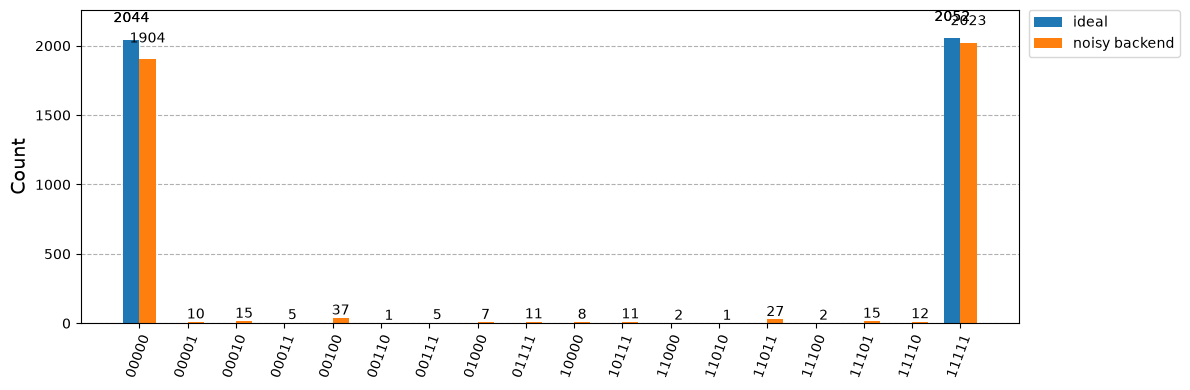

In [13]:
plot_histogram(
    [ideal_counts, noisy_simulator_counts],
    legend=["ideal", "noisy backend"],
    figsize=(12, 4)
)

The ideal simulator should put almost all probability on `00...0` and `11...1`.
The fake backend should still preserve those two outcomes as the most important ones, but it usually assigns some weight to additional bitstrings as well.

# Chapter 2 — What kind of noise do we care about?

Before discussing noise, it is useful to slightly generalize how we describe quantum states.

So far, a quantum state may have been written as a statevector, such as $|\psi\rangle$.
This is enough for an ideal, perfectly isolated quantum system.
However, real quantum computers are not perfectly isolated: qubits interact weakly with their environment, gates are imperfect, and measurements are noisy.
To describe these situations, we use a **density matrix** $\rho$.

For a pure state $|\psi\rangle$, the density matrix is

$$
\rho = |\psi\rangle\langle\psi|.
$$

More generally, $\rho$ can also represent a **mixed state**, where the system is in different quantum states with different probabilities.
This makes density matrices a natural language for noisy quantum systems.

A **quantum channel** is a mathematical description of a physical process acting on a density matrix:

$$
\rho \mapsto \mathcal{E}(\rho).
$$

An ideal quantum gate is a special case of a quantum channel. If the gate is represented by a unitary matrix $U$, then

$$
\rho \mapsto U\rho U^\dagger.
$$

Noise is also described by quantum channels, but generally not by a single unitary operation on the system alone. Instead, noisy channels capture effects such as random gate errors, loss of phase coherence, relaxation toward $|0\rangle$, and imperfect measurement.

<div class="alert alert-block alert-info">
For more background on density matrices, see this lesson in IBM Quantum Learning:
<a href="https://quantum.cloud.ibm.com/learning/courses/general-formulation-of-quantum-information/density-matrices/density-matrix-basics">
Density matrix basics
</a>.
</div>

In this chapter, we study three important models of noise. These are not the only noise mechanisms that matter on real hardware, but they are useful models for developing intuition. Each one behaves differently.

| Noise model | What it represents | Channel form |
|---|---|---|
| **Depolarization error** | A simple model of gate imperfection where the state is partially randomized. | $$\rho \mapsto (1-\lambda)\rho + \lambda \frac{I}{2}$$ |
| **Pauli error** | A structured stochastic error model using $X$, $Y$, and $Z$ errors. | $$\rho \mapsto p_I \rho + p_X X\rho X + p_Y Y\rho Y + p_Z Z\rho Z$$ |
| **Thermal relaxation** | A time-dependent noise model related to energy relaxation and dephasing. | $$\rho=\begin{pmatrix}\rho_{00}&\rho_{01}\\ \rho_{10}&\rho_{11}\end{pmatrix} \mapsto \begin{pmatrix}\rho_{00}+(1-e^{-t/T_1})\rho_{11}&e^{-t/T_2}\rho_{01}\\ e^{-t/T_2}\rho_{10}&e^{-t/T_1}\rho_{11}\end{pmatrix}$$ |


<div class="alert alert-block alert-info">
For more classes of quantum errors, see the
<a href="https://quantum.cloud.ibm.com/docs/guides/build-noise-models#quantum-errors">
list of quantum errors
</a>.
</div>

### 2.1 Depolarization error

Depolarization is the simplest way to say:

> after a gate, the state becomes partially randomized.

This model is useful because it captures the idea of an imperfect gate without committing to a detailed physical mechanism.  
For a single qubit, the depolarizing channel can be written schematically as
$$
\rho \mapsto (1-\lambda)\rho + \lambda \frac{I}{2},
$$
where a larger $\lambda$ means more randomization.

In order to observe the effect of depolarization, we can design a simple experiment:

- start from $|0\rangle$,
- apply an even number $2n$ of `x` gates,
- measure in the computational basis,
- observe how the survival probability $\Pr(0)$ decreases as $n$ grows.

In an ideal circuit, an even number of `x` gates returns the qubit to $|0\rangle$ exactly.
Under depolarizing noise, the state becomes partially randomized after passing each of the gates, which becomes less reliable as the sequence length $n$ grows.

Now, let's visualize the effect of the noise and measure them.

<div class="alert alert-block alert-success">
<b>Exercise 2.</b>
    Given n, create a function that returns a single-qubit quantum circuit applying 2n of X gates and a measurement gate.
</div>

Example circuit for the repeated X experiment with n=4:


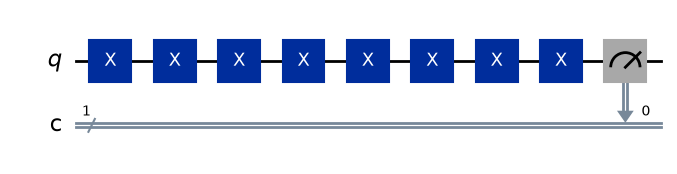

In [14]:
def repeated_x_circuit(n):
    qc = QuantumCircuit(1, 1)

    for _ in range(2 * n):
        qc.x(0)

    qc.measure(0, 0)

    return qc

print("Example circuit for the repeated X experiment with n=4:")
display(repeated_x_circuit(4).draw("mpl"))

In [15]:
grade_lab2_ex2(repeated_x_circuit)

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. You have correctly implemented the repeated X circuit. 

You scored 1 on this exercise.


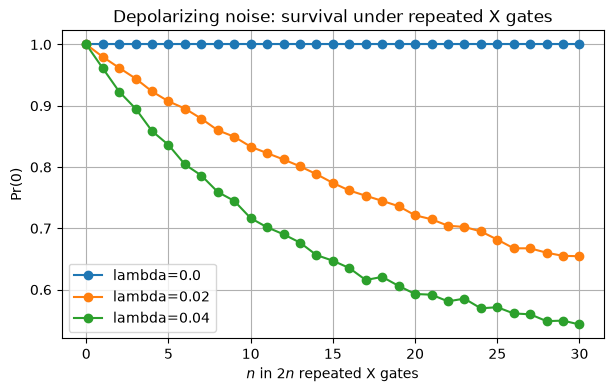

In [16]:
def depol_x_simulator(lam):
    noise_model = NoiseModel()

    error = depolarizing_error(lam, 1)
    noise_model.add_all_qubit_quantum_error(error, ["x"])

    return AerSimulator(noise_model=noise_model)

lambdas = [0.00, 0.02, 0.04]
n_values = list(range(0, 31))

shots = 20_000

fig, ax = plt.subplots(figsize=(7, 4))

p0 = {}

for lam in lambdas:
    backend = depol_x_simulator(lam)
    p0[lam] = []
    for n in n_values:
        qc = repeated_x_circuit(n)
        counts = run_counts(backend, qc, shots=shots)
        p0[lam].append(prob_of_zero(counts))
    ax.plot(n_values, p0[lam], marker="o", label=f"lambda={lam}")

ax.set_xlabel("$n$ in $2n$ repeated X gates")
ax.set_ylabel("Pr(0)")
ax.set_title("Depolarizing noise: survival under repeated X gates")
ax.legend()
ax.grid(True)
plt.show()

Even though an ideal sequence of `2n` `x` gates should always return the qubit to $|0\rangle$, the observed probability $\Pr(0)$ decreases as the sequence gets longer and the depolarization error becomes more severe.

This is a direct visual example of **noise accumulation**.

In theory, after each noisy `x` gate, the information is shrunk by a factor of $(1-\lambda)$. Since the circuit contains $2n$ noisy `x` gates, the survival probability becomes

$$
\Pr(0)
=
\frac{1 + (1-\lambda)^{2n}}{2}.
$$

This means that $\Pr(0)$ decays exponentially toward $1/2$, which corresponds to a completely randomized single-qubit state. Therefore, by fitting the measured survival probability to this curve, we can estimate the depolarization parameter $\lambda$.

The code below uses `curve_fit` from `scipy.optimize` to find the value of $\lambda$ that best matches the observed data. For each simulated noise strength, it compares the sampled probabilities with the fitted curve, plots both on the same graph, and summarizes the true and fitted values of $\lambda$ in a table.

Because the probabilities are estimated from a finite number of shots, the fitted value does not have to match the input value exactly. However, if the model is correct and the number of shots is large enough, the fitted $\lambda$ should be close to the value used in the simulator.

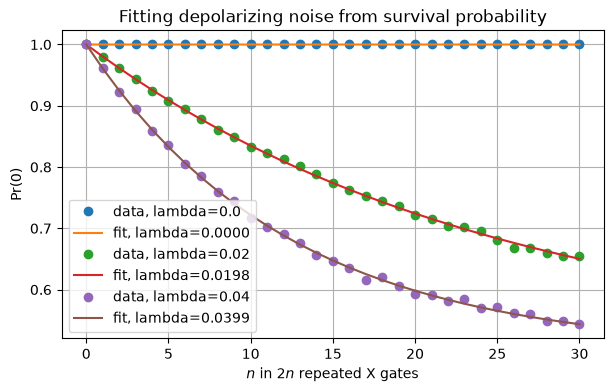

,true lambda,fitted lambda,fit std
0,0.00,9.858382e-07,1.799926e-07
1,0.02,1.984575e-02,6.708448e-05
2,0.04,3.986806e-02,1.800321e-04


In [17]:
def depol_survival_model(n, lam):
    return 0.5 + 0.5 * (1 - lam) ** (2 * n)

fit_rows = []

fig, ax = plt.subplots(figsize=(7, 4))

for lam_true in lambdas:
    y_data = np.array(p0[lam_true])

    popt, pcov = curve_fit(
        depol_survival_model,
        n_values,
        y_data,
        p0=[0.01],
        bounds=(0.0, 1.0),
    )

    lam_fit = popt[0]
    lam_std = np.sqrt(np.diag(pcov))[0]

    fit_rows.append({
        "true lambda": lam_true,
        "fitted lambda": lam_fit,
        "fit std": lam_std,
    })

    ax.plot(n_values, y_data, "o", label=f"data, lambda={lam_true}")
    ax.plot(
        n_values,
        depol_survival_model(np.array(n_values), lam_fit),
        "-",
        label=f"fit, lambda={lam_fit:.4f}",
    )

ax.set_xlabel("$n$ in $2n$ repeated X gates")
ax.set_ylabel("Pr(0)")
ax.set_title("Fitting depolarizing noise from survival probability")
ax.legend()
ax.grid(True)
plt.show()

fit_df = pd.DataFrame(fit_rows)
display(fit_df)

### 2.2 Pauli error

Pauli error is more structured than depolarization.

After each gate, one of the Pauli operations, $I$, $X$, $Y$, or $Z$, is applied with a certain probability:

$$
\rho \mapsto p_I \rho + p_X X\rho X + p_Y Y\rho Y + p_Z Z\rho Z,
$$

where
$
p_I = 1 - p_X - p_Y - p_Z.
$

If the non-identity error probabilities are uniform,
$$
p_X = p_Y = p_Z = \frac{\lambda}{4},
$$
then this Pauli error model becomes identical to the depolarization model stated above.

The key difference is that Pauli error allows the noise to be stronger along one direction than another. In other words, the error does not have to randomize the state equally in all directions.

For example, we can identify two important types of Pauli errors:

- **Bit-flip-like errors**, caused by $X$ and $Y$ errors, which can change computational-basis states such as $|0\rangle$ and $|1\rangle$.
- **Phase-flip-like errors**, caused by $Z$ and $Y$ errors, which can change the relative phase between basis states.

The $Y$ error appears in both categories because, up to a global phase,

$$
Y = iXZ.
$$

Therefore, an $Y$ error acts like a combination of a bit flip and a phase flip.

This is why a single experiment is not enough to tell the whole story. A bit-flip-like error can be easy to see in one basis and almost invisible in another. Likewise, a phase-flip-like error can be completely hidden if we only prepare computational-basis states and measure in the computational basis.

We therefore use **two complementary experiments**.

#### Experiment A: bit-flip-sensitive test

We use the same repeated-`x` experiment as in the depolarization case.

The difference is in how we interpret the result. Under Pauli noise, the survival probability $\Pr(0)$ mainly reveals the bit-flip-like part of the error channel.

Errors with an $X$ component can change $|0\rangle$ into $|1\rangle$, so they are directly visible in computational-basis measurement. A $Y$ error also contributes to this behavior because it contains a bit-flip component. In contrast, a pure $Z$ error only changes the phase and is therefore not visible when we only measure in the computational basis.

Therefore, this experiment is useful for detecting $X$- and $Y$-type errors, but it is not sensitive to pure $Z$-type phase errors.

#### Experiment B: phase-flip-sensitive test

We now use a complementary version of the repeated-`x` experiment.

Instead of starting from $|0\rangle$, we start from the $X$-basis state $|+\rangle$ by applying a Hadamard gate:

$$
|0\rangle \mapsto |+\rangle.
$$

Then we apply the same repeated `x` gates and finally measure in the $X$ basis. In the circuit, measuring in the $X$ basis can be implemented by applying another Hadamard gate before the computational-basis measurement.

The survival probability $\Pr(0)$ now represents the probability that the final state is still $|+\rangle$.

This experiment is sensitive to phase-flip-like errors. A pure $Z$ error changes

$$
|+\rangle \mapsto |-\rangle,
$$

so it becomes directly visible in the $X$-basis measurement. A $Y$ error also contributes because it contains a phase-flip component. In contrast, a pure $X$ error does not change $|+\rangle$ except for an eigenvalue phase, since

$$
X|+\rangle = |+\rangle.
$$

Therefore, this experiment is useful for detecting $Z$- and $Y$-type errors, but it is not sensitive to pure $X$-type bit-flip errors.

<div class="alert alert-block alert-success">
<b>Exercise 3.</b>
    <br>
   Given n, create a function that returns a single-qubit quantum circuit applying 2n x gates to the |+> state and measuring the state in x basis. <b>Hint</b>: Apply Hadamard gates before and after applying 2n x gates.<br>
</div>

In [18]:

def repeated_x_meas_x_circuit(n):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    for _ in range(2 * n):
        qc.x(0)

    qc.h(0)
    qc.measure(0, 0)
    
    return qc


In [19]:
## Verify your answer ##
grade_lab2_ex3(repeated_x_meas_x_circuit)

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. You have correctly implemented the repeated X circuit measured in the X basis. 

You scored 1 on this exercise.


Circuit for Experiment A (bit-flip-sensitive test) with n=5:


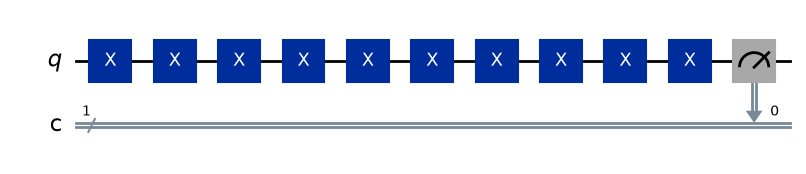


Circuit for Experiment B (phase-flip-sensitive test) with n=5:


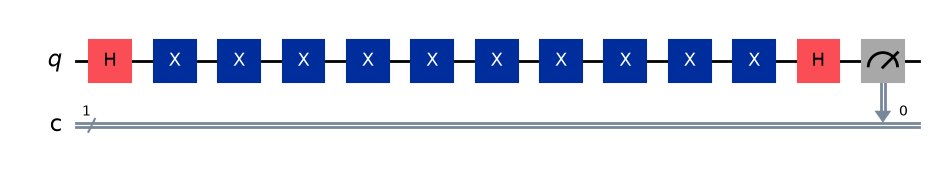

In [20]:
n = 5
print(f"Circuit for Experiment A (bit-flip-sensitive test) with n={n}:")
display(repeated_x_circuit(n).draw("mpl"))
print(f"\nCircuit for Experiment B (phase-flip-sensitive test) with n={n}:")
display(repeated_x_meas_x_circuit(n).draw("mpl"))

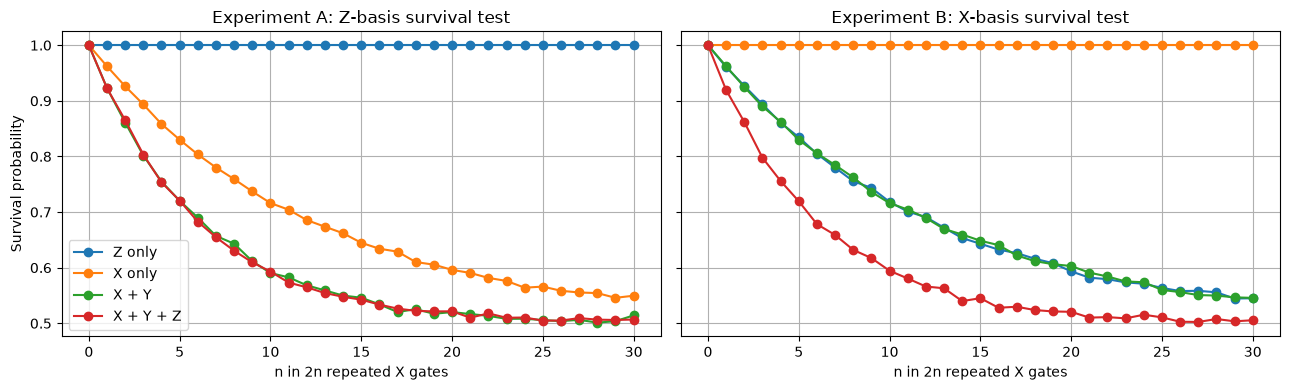

In [21]:
pauli_cases = {
    "Z only":       {"px": 0.00, "py": 0.00, "pz": 0.02},
    "X only":       {"px": 0.02, "py": 0.00, "pz": 0.00},
    "X + Y":        {"px": 0.02, "py": 0.02, "pz": 0.00},
    "X + Y + Z":    {"px": 0.02, "py": 0.02, "pz": 0.02},
}

n_values = list(range(0, 31))

fig, axs = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for label, probs in pauli_cases.items():
    px, py, pz = probs["px"], probs["py"], probs["pz"]

    # Build the Pauli noise model
    noise_model_pauli = NoiseModel()
    noise_model_pauli.add_all_qubit_quantum_error(
        pauli_error([
            ("I", 1 - px - py - pz),
            ("X", px),
            ("Y", py),
            ("Z", pz),
        ]),
        ["x"],
    )
    backend_pauli = AerSimulator(noise_model=noise_model_pauli)

    p0_z_basis = []
    p0_x_basis = []

    for n in n_values:
        # Experiment A: Z-basis survival test
        qc_z = repeated_x_circuit(n)
        counts_z = run_counts(backend_pauli, qc_z, shots=shots)
        p0_z_basis.append(prob_of_zero(counts_z))

        # Experiment B: X-basis survival test
        qc_x = repeated_x_meas_x_circuit(n)
        counts_x = run_counts(backend_pauli, qc_x, shots=shots)
        p0_x_basis.append(prob_of_zero(counts_x))

    axs[0].plot(n_values, p0_z_basis, marker="o", label=label)
    axs[1].plot(n_values, p0_x_basis, marker="o", label=label)

axs[0].set_title("Experiment A: Z-basis survival test")
axs[0].set_xlabel("n in 2n repeated X gates")
axs[0].set_ylabel("Survival probability")
axs[0].grid(True)

axs[1].set_title("Experiment B: X-basis survival test")
axs[1].set_xlabel("n in 2n repeated X gates")
axs[1].grid(True)

axs[0].legend()
# axs[1].legend()

plt.tight_layout()
plt.show()

The two panels show the same Pauli error cases viewed in two different bases.

In the $Z$-basis test, the survival probability mainly decreases when the noise contains an $X$ or $Y$ component. A pure $Z$ error barely changes the result, because its effect is only a phase change in the computational basis.

The opposite pattern appears in the $X$-basis test. There, a pure $X$ error is almost invisible, while $Z$ and $Y$ errors reduce the survival probability because they move $|+\rangle$ toward $|-\rangle$.

<div class="alert alert-block alert-success">
<b>Exercise 4.</b>
    <br>
    For each Pauli error, identify whether it can change the final measurement outcome in the Z-basis and X-basis, using repeated-X experiments.
</div>

In [24]:
# Replace every None with either True or False.
answer_pauli_visibility = {
    "X error": {
        "bit-flip sensitive": True,
        "phase-flip sensitive": False,
    },
    "Y error": {
        "bit-flip sensitive": True,
        "phase-flip sensitive": True,
    },
    "Z error": {
        "bit-flip sensitive": False,
        "phase-flip sensitive": True,
    },
}

print("Submitted answer")
for error, contents in answer_pauli_visibility.items():
    for experiment, visibility in contents.items():
        if visibility is None:
            print(f"\t{error}: no answer submitted for the {experiment} experiment.")
        elif visibility:
            print(f"\t{error} can be observed in the {experiment} experiment.")
        else:
            print(f"\t{error} cannot be observed in the {experiment} experiment.")

Submitted answer
	X error can be observed in the bit-flip sensitive experiment.
	X error cannot be observed in the phase-flip sensitive experiment.
	Y error can be observed in the bit-flip sensitive experiment.
	Y error can be observed in the phase-flip sensitive experiment.
	Z error cannot be observed in the bit-flip sensitive experiment.
	Z error can be observed in the phase-flip sensitive experiment.


In [25]:
grade_lab2_ex4(answer_pauli_visibility)

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. You have correctly identified which Pauli errors are detectable in the bit-flip-sensitive and phase-flip-sensitive experiments.

You scored 1 on this exercise.


### 2.3 Thermal relaxation

Thermal relaxation is different from two errors, where the noise applies **per gate**, but rather

> **noise per unit time.**

Since time itself becomes a source of error, even if two circuits perform the same logical operation, their performance can differ if one takes longer to execute.

In the previous models, we mainly asked what happens when an imperfect gate is applied. In thermal relaxation, we ask what happens simply because time passes while the qubit is not perfectly isolated from its environment.

Two standard parameters describe this effect:

- $T_1$: energy relaxation time,
- $T_2$: phase coherence time (**dephasing**).

Roughly speaking, $T_1$ describes how quickly an excited state $|1\rangle$ decays toward the ground state $|0\rangle$. Meanwhile, $T_2$ describes how quickly phase coherence is lost between $|0\rangle$ and $|1\rangle$.

For a single-qubit density matrix,

$$
\rho =
\begin{pmatrix}
\rho_{00} & \rho_{01} \\
\rho_{10} & \rho_{11}
\end{pmatrix},
$$

a simplified thermal relaxation model can be written as

$$
\rho(t)=
\begin{pmatrix}
\rho_{00} + (1-e^{-t/T_1})\rho_{11} & e^{-t/T_2}\rho_{01} \\
e^{-t/T_2}\rho_{10} & e^{-t/T_1}\rho_{11}
\end{pmatrix}.
$$

This expression shows two different effects. The excited-state population $\rho_{11}$ shrinks over time due to $T_1$ relaxation, while the off-diagonal coherence terms $\rho_{01}$ and $\rho_{10}$ shrink due to $T_2$ dephasing.

**Delay experiments** are useful for studying thermal relaxation. By inserting idle time into a circuit, we can separate the effect of elapsed time from the effect of applying many imperfect gates.

#### Experiment A: $T_1$-type decay

We prepare $|1\rangle$, wait for a controllable delay time, and measure in the computational basis.

This experiment mainly tracks population decay. If the delay becomes longer, the excited state is increasingly likely to relax toward $|0\rangle$.

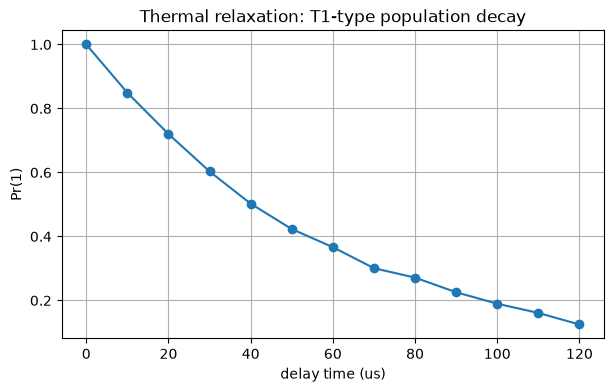

In [26]:
def t1_delay_circuit(delay_dt):
    qc = QuantumCircuit(1, 1)
    qc.x(0)
    qc.delay(delay_dt, 0, unit="ns")
    qc.measure(0, 0)
    return qc

t1_us = 60
t2_us = 40

delay_values_ns = np.linspace(0, 120_000, 13)  # 0 to 120 us
p1_vals = []

for delay_ns in delay_values_ns:
    noise_model = NoiseModel()
    err = thermal_relaxation_error(t1_us * 1e3, t2_us * 1e3, time=delay_ns)
    noise_model.add_all_qubit_quantum_error(err, ["delay"])
    backend = AerSimulator(noise_model=noise_model)

    qc = t1_delay_circuit(int(delay_ns))
    counts = transpile_and_run_counts(backend, qc, shots=4096)
    p1 = counts.get("1", 0) / sum(counts.values())
    p1_vals.append(p1)

plt.figure(figsize=(7, 4))
plt.plot(delay_values_ns / 1000, p1_vals, marker="o")
plt.xlabel("delay time (us)")
plt.ylabel("Pr(1)")
plt.title("Thermal relaxation: T1-type population decay")
plt.grid(True)
plt.show()

#### Experiment B: $T_2$-type coherence decay

Now we prepare $|+\rangle$, insert a delay, and measure in the $X$ basis.

This experiment tracks how phase coherence is lost over time. Even when population has not fully relaxed, coherence can still decay, which means superposition-based behavior becomes harder to preserve.

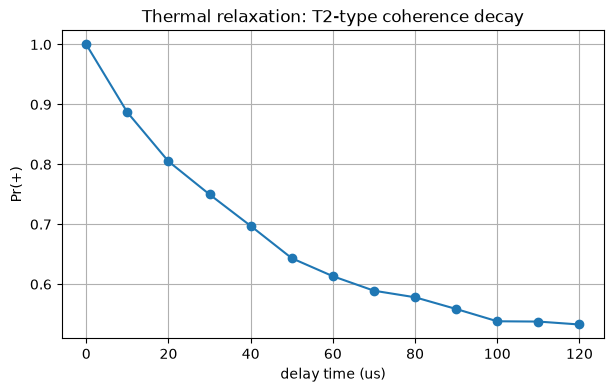

In [27]:
def t2_delay_circuit(delay_dt):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.delay(delay_dt, 0, unit="ns")
    qc.h(0)
    qc.measure(0, 0)
    return qc

pplus_vals = []

for delay_ns in delay_values_ns:
    noise_model = NoiseModel()
    err = thermal_relaxation_error(t1_us * 1e3, t2_us * 1e3, time=delay_ns)
    noise_model.add_all_qubit_quantum_error(err, ["delay"])
    backend = AerSimulator(noise_model=noise_model)

    qc = t2_delay_circuit(int(delay_ns))
    counts = transpile_and_run_counts(backend, qc, shots=4096)
    pplus_vals.append(prob_of_zero(counts))

plt.figure(figsize=(7, 4))
plt.plot(delay_values_ns / 1000, pplus_vals, marker="o")
plt.xlabel("delay time (us)")
plt.ylabel("Pr(+)")
plt.title("Thermal relaxation: T2-type coherence decay")
plt.grid(True)
plt.show()

### 2.4 Quick summary of the three toy models

- **Depolarization:** isotropic gate imperfection.
- **Pauli error:** directional stochastic $X/Y/Z$ error.
- **Thermal relaxation:** time-dependent decay governed by $T_1$ and $T_2$.

These models are simplified, but they help us interpret what we observe on more realistic backends. The important point is not to memorize the labels, but to connect each model to a physical intuition: randomization, directionality, and time dependence.

# Chapter 3 — Comparing Heron and Nighthawk Architectures

Real quantum processors exhibit diverse architectures, each characterized by unique connectivity patterns and performance characteristics that fundamentally impact quantum algorithm execution. This section examines two IBM Quantum architectures: the Heron Architecture, which employs a Heavy-Hex topology featuring a hexagonal lattice pattern optimized for error correction, and the Nighthawk Architecture, which offers alternative connectivity optimized for specific quantum operations. Understanding these architectural differences is crucial because the physical layout of qubits directly determines which qubits can interact, the number of SWAP gates required (and thus circuit overhead), overall circuit depth and fidelity, and ultimately, algorithm performance on real hardware.

## 3.1 Layout Comparison

The layout in a QPU is the mapping of logical qubits to physical qubits in real quantum hardware. This concept is fundamental to understanding how quantum circuits are executed on real processors, as it establishes the correspondence between the abstract qubits we define in our algorithm and the physical qubits that exist in the quantum device.

Logical qubits are the abstract units we use when designing a quantum circuit, typically represented as q[0], q[1], q[2], etc. On the other hand, physical qubits are the real elements of quantum hardware, each with a specific physical position and particular characteristics such as error rates and coherence times. The distinction between these two types of qubits is crucial because quantum hardware has physical limitations that do not exist in the abstract model.

When constructing a quantum circuit, physical qubits are assigned by default to their corresponding logical qubits, as demonstrated in this example.

In [28]:
# virtual layout
layout = {idx:value for  idx,value in enumerate(qc_ghz.qregs[0])}

layout

{0: <Qubit register=(5, "q"), index=0>,
 1: <Qubit register=(5, "q"), index=1>,
 2: <Qubit register=(5, "q"), index=2>,
 3: <Qubit register=(5, "q"), index=3>,
 4: <Qubit register=(5, "q"), index=4>}

Through transpilation, it is possible to specify which physical hardware qubits should be assigned to logical qubits, though this depends on the hardware configuration. A specific example is demonstrated below using the initial_layout attribute.

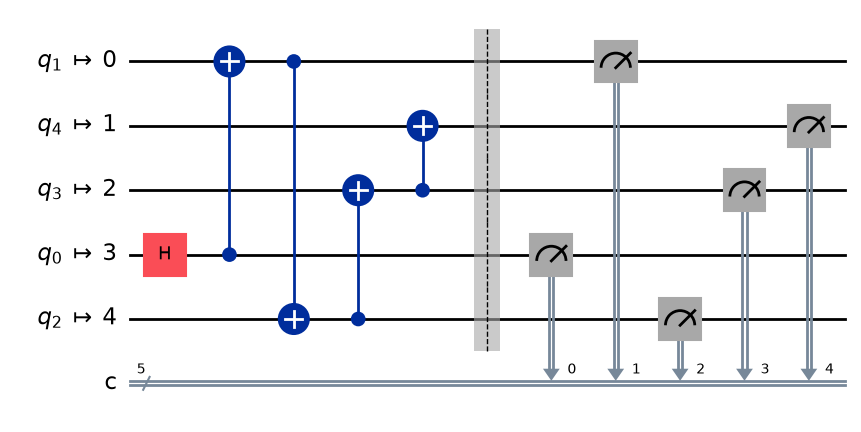

In [29]:
qc_ghz_init_1 = transpile(qc_ghz, initial_layout=[3,0,4,2,1])

qc_ghz_init_1.draw('mpl')

QPUs have specific topologies that determine which pairs of qubits can interact directly. For example, the 'Heron' architecture uses a heavy-hex (heavy hexagonal) topology, while the 'Nighthawk' architecture features a different connectivity pattern optimized for specific quantum operations. Other processors may have chain, grid, or custom topologies. In these topologies, only certain pairs of physical qubits are connected and can execute two-qubit gates such as CNOT or CZ directly. This limited connectivity is a physical constraint of the hardware that must be considered when mapping logical qubits to physical qubits. The choice between architectures like Heron and Nighthawk can significantly impact circuit performance, as their distinct connectivity patterns may favor different types of quantum algorithms or problem structures.

In [30]:
backend_heron = FakeTorino()  # heron architecture
backend_nighthawk = FakeNighthawk()  #Nighthwak architecture

Visualize the topologies of both backends

MissingOptionalLibraryError: "The 'Graphviz' library is required to use 'plot_coupling_map'.  To install, follow the instructions at https://graphviz.org/download/. Qiskit needs the Graphviz binaries, which the 'graphviz' package on pip does not install. You must install the actual Graphviz software."

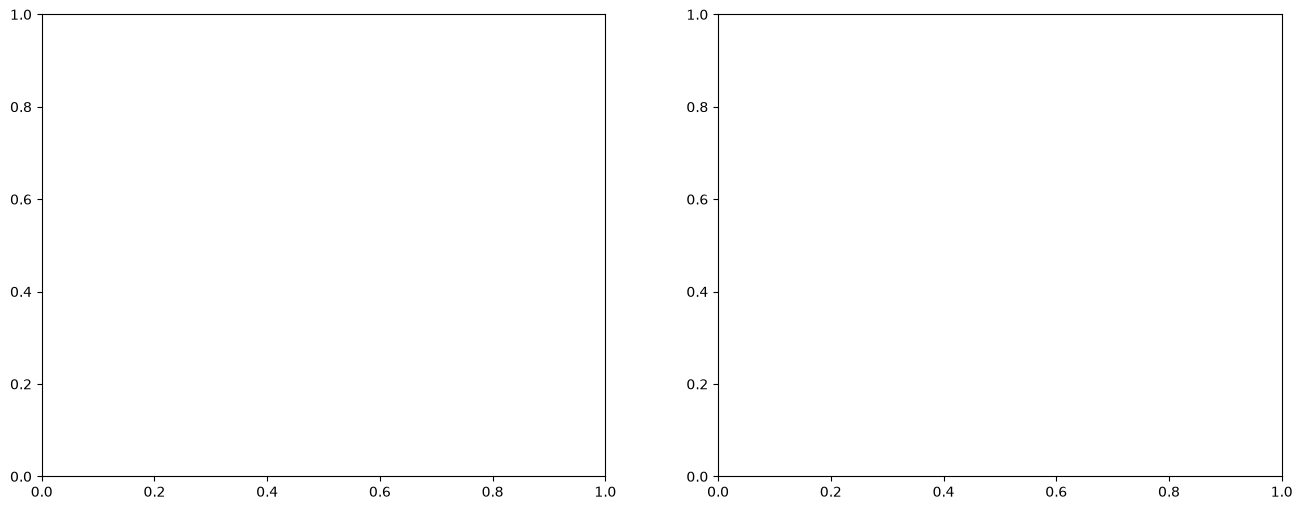

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heavy-hex layout
plot_gate_map(backend_heron, ax=axes[0])
axes[0].set_title(f"Heavy-hex Layout\n({backend_heron.num_qubits} qubits)", fontsize=14, fontweight='bold')

# Nighthawk layout
plot_gate_map(backend_nighthawk, ax=axes[1])
axes[1].set_title(f"Nighthawk Layout\n({backend_nighthawk.num_qubits} qubits)", fontsize=14, fontweight='bold')

plt.tight_layout()
#plt.show()

coupling_map_heron = backend_heron.coupling_map
coupling_map_night = backend_nighthawk.coupling_map

print(f"\nConnectivity Statistics:")
print(f"Heavy-hex: {len(coupling_map_heron.get_edges())} edges")
print(f"Nighthawk: {len(coupling_map_night.get_edges())} edges")
print(f"Average degree (Heavy-hex): {2 * len(coupling_map_heron.get_edges()) / backend_heron.num_qubits:.2f}")
print(f"Average degree (Nighthawk): {2 * len(coupling_map_night.get_edges()) / backend_nighthawk.num_qubits:.2f}")

The importance of layout lies in its direct impact on the quality and feasibility of quantum circuit execution. A poor layout occurs when logical qubits that need to interact in the circuit are mapped to physical qubits that are not directly connected in the hardware. In these cases, the compiler must insert additional SWAP operations to move quantum states between qubits, allowing the desired interaction to finally occur. These SWAP operations have multiple negative consequences: they increase circuit depth (the number of sequential gate layers), increase the total number of gates that must be executed, accumulate more error due to the imperfections of each additional gate, and reduce the fidelity of the final result due to quantum decoherence that occurs during the extra execution time.

Conversely, a good layout minimizes or eliminates the need for SWAP operations by intelligently assigning logical qubits that interact frequently to physical qubits that are directly connected in the hardware topology. This optimal mapping preserves the structure of the original circuit as much as possible, reducing transpilation overhead and maximizing the probability of obtaining accurate results. In variational algorithms such as QAOA, where circuit depth and gate fidelity are critical to performance, the difference between an optimal layout and a suboptimal one can determine the success or failure of the entire quantum experiment.

In [33]:
num_qubits = 120
qc_ghz_120 = QuantumCircuit(num_qubits,num_qubits) 
qc_ghz_120.h(0)

for idx in range(num_qubits-1):
    qc_ghz_120.cx(idx,idx+1)

qc_ghz_120.measure(range(num_qubits),range(num_qubits))
qc_ghz_120.draw('mpl',fold=-1)

<div class="alert alert-block alert-success">
<b>Exercise 5 a).</b>
    <br>
   Create an <b>initial_layout</b> that goes in ascending order starting from q0 up to the maximum number of qubits in the <b>qc_ghz_120</b> circuit, and also specify that the quantum circuit's <b>basis_gates</b> can only be h, cx, and swap gates.<br>
</div>

In [40]:
initial_layout = list(range(120))
basis_gates = ["h", "cx", "swap"]

# Transpile for Heavy-hex backend
print("Transpiling GHZ circuit for Heavy-hex architecture...")

transpiled_heron = transpile(
    qc_ghz_120,
    backend=backend_heron,
    optimization_level=3,
    initial_layout=initial_layout,
    seed_transpiler=20,
    basis_gates=basis_gates,
)

# Transpile for Nighthawk backend
print("Transpiling GHZ circuit for Nighthawk architecture...")

transpiled_nightawk = transpile(
    qc_ghz_120,
    backend=backend_nighthawk,
    optimization_level=3,
    initial_layout=initial_layout,
    seed_transpiler=20,
    basis_gates=basis_gates,
)

Transpiling GHZ circuit for Heavy-hex architecture...
Transpiling GHZ circuit for Nighthawk architecture...


<div class="alert alert-block alert-success">
<b>Exercise 5 b).</b>
    <br>
  Complete the count_swap_gates function to detect how many SWAP gates were used in the circuit.<br>
</div>

In [41]:
def count_swap_gates(circuit: QuantumCircuit) -> int:
    """
    Count the number of SWAP gates in a circuit.

    Args:
        circuit: The QuantumCircuit to analyze.

    Returns:
        The number of SWAP gates in the circuit.

    Hint:
        - Iterate over circuit.data to access each instruction
        - Each instruction has an .operation.name attribute
        - Check if the name equals "swap"
    """
    swap_count = 0
    
    for instruction in circuit.data:
        if instruction.operation.name == "swap":
            swap_count += 1

    return swap_count



# Print comparison
print("GHZ Circuit Transpilation Comparison")
print(f"\n{'Metric':<30} {'Heavy-hex':<15} {'Nighthawk':<15}")
print(f"{'Circuit Depth':<30} {transpiled_heron.depth():<15} {transpiled_nightawk.depth():<15}")
print(f"{'Total Gates':<30} {transpiled_heron.size():<15} {transpiled_nightawk.size():<15}")
print(f"{'Two-qubit Gates':<30} {transpiled_heron.num_nonlocal_gates():<15} {transpiled_nightawk.num_nonlocal_gates():<15}")
print(f"{'SWAP Gates':<30} {count_swap_gates(transpiled_heron):<15} {count_swap_gates(transpiled_nightawk):<15}")



GHZ Circuit Transpilation Comparison

Metric                         Heavy-hex       Nighthawk      
Circuit Depth                  298             220            
Total Gates                    463             339            
Two-qubit Gates                342             218            
SWAP Gates                     223             99             


In [42]:
grade_lab2_ex5(
    initial_layout = initial_layout,
    basis_gates = basis_gates,
    count_swap_gates= count_swap_gates
) 

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. You have correctly implemented count_swap_gates, initial_layout, and basis_gates. 

You scored 1 on this exercise.


## 3.2 Benchmarking the Previous IBM QPUs




In [43]:
def backend_summary_detail(backend):
    conf = backend.configuration()
    props = backend.properties()
    n_qubits = backend.num_qubits

    # T1/T2/readout from BackendProperties.
    t1s, t2s, readout_errs = [], [], []
    for q in range(n_qubits):
        t1s.append(props.t1(q))
        t2s.append(props.t2(q))
        readout_errs.append(props.readout_error(q))
    
    gate_errs = dict()
    for gate in conf.gates:
        gate = gate.to_dict()
        if (gate["name"] in ["reset", "measure", "rz"]): # "rz" has no error
            continue
        for applied_qubits in gate["coupling_map"]:
            applied_qubits = tuple(applied_qubits)
            if applied_qubits not in gate_errs:
                gate_errs[applied_qubits] = list()
            gate_errs[applied_qubits].append(props.gate_error(gate["name"], applied_qubits))

    twoq_errs, oneq_errs = list(), list()
    for qubits, err in gate_errs.items():
        if len(qubits) == 1:
            oneq_errs.append(err)
        elif len(qubits) == 2:
            twoq_errs.append(err)
        else:
            raise Exception

    if n_qubits < 10:
        size_family = "small: <10 qubits"
    elif n_qubits < 120:
        size_family = "medium: <120 qubits"
    else:
        size_family = "large: >=120 qubits"

    return {
        "name": backend.name,
        "date": backend.online_date,
        "n_qubits": n_qubits,
        "n_coupling_edges": len(backend.coupling_map.get_edges())//2,
        "t1_median_us": np.median(t1s) * 1e6,
        "t2_median_us": np.median(t2s) * 1e6,
        "readout_error_median": np.median(readout_errs),
        "oneq_error_median": np.median(oneq_errs),
        "twoq_error_median": np.median(twoq_errs),
        "size_family": size_family
    }


In [44]:
provider = FakeProviderForBackendV2()
backends = provider.backends()

rows = []
for backend in backends:
    if backend.name == "fake_armonk":  # single-qubit processor
        continue
    rows.append(backend_summary_detail(backend))

df = pd.DataFrame(rows)

# Remove pure test backend if desired.
# df = df[df["name"] != "fake_fractional_backend"]

df = df.sort_values(["date", "name"], na_position="last").reset_index(drop=True)

display_cols = [
    "date",
    "name",
    "n_qubits",
    "size_family",
    "t1_median_us",
    "t2_median_us",
    "oneq_error_median",
    "twoq_error_median",
    "readout_error_median",
    "n_coupling_edges",
]

display(df[display_cols].head(3))
print("...")
display(df[display_cols].tail(3))

,date,name,n_qubits,size_family,t1_median_us,t2_median_us,oneq_error_median,twoq_error_median,readout_error_median,n_coupling_edges
0,2017-01-24 05:00:00+00:00,fake_yorktown,5,small: <10 qubits,48.233935,24.545081,0.001304,0.021423,0.0633,6
1,2018-08-29 04:00:00+00:00,fake_poughkeepsie,20,medium: <120 qubits,66.944812,80.280488,0.001099,0.020872,0.0420,23
2,2018-11-06 05:00:00+00:00,fake_melbourne,15,medium: <120 qubits,53.161052,54.902415,0.001061,0.029042,0.0476,20


...


,date,name,n_qubits,size_family,t1_median_us,t2_median_us,oneq_error_median,twoq_error_median,readout_error_median,n_coupling_edges
56,2024-05-14 04:00:00+00:00,fake_fez,156,large: >=120 qubits,144.855266,87.950687,0.000229,0.003903,0.007568,176
57,2024-08-07 04:00:00+00:00,fake_marrakesh,156,large: >=120 qubits,197.358376,118.426260,0.000230,0.003295,0.009521,176
58,2025-11-01 04:00:00+00:00,fake_nighthawk,120,large: >=120 qubits,272.790084,341.633502,0.000148,0.002709,0.004883,218


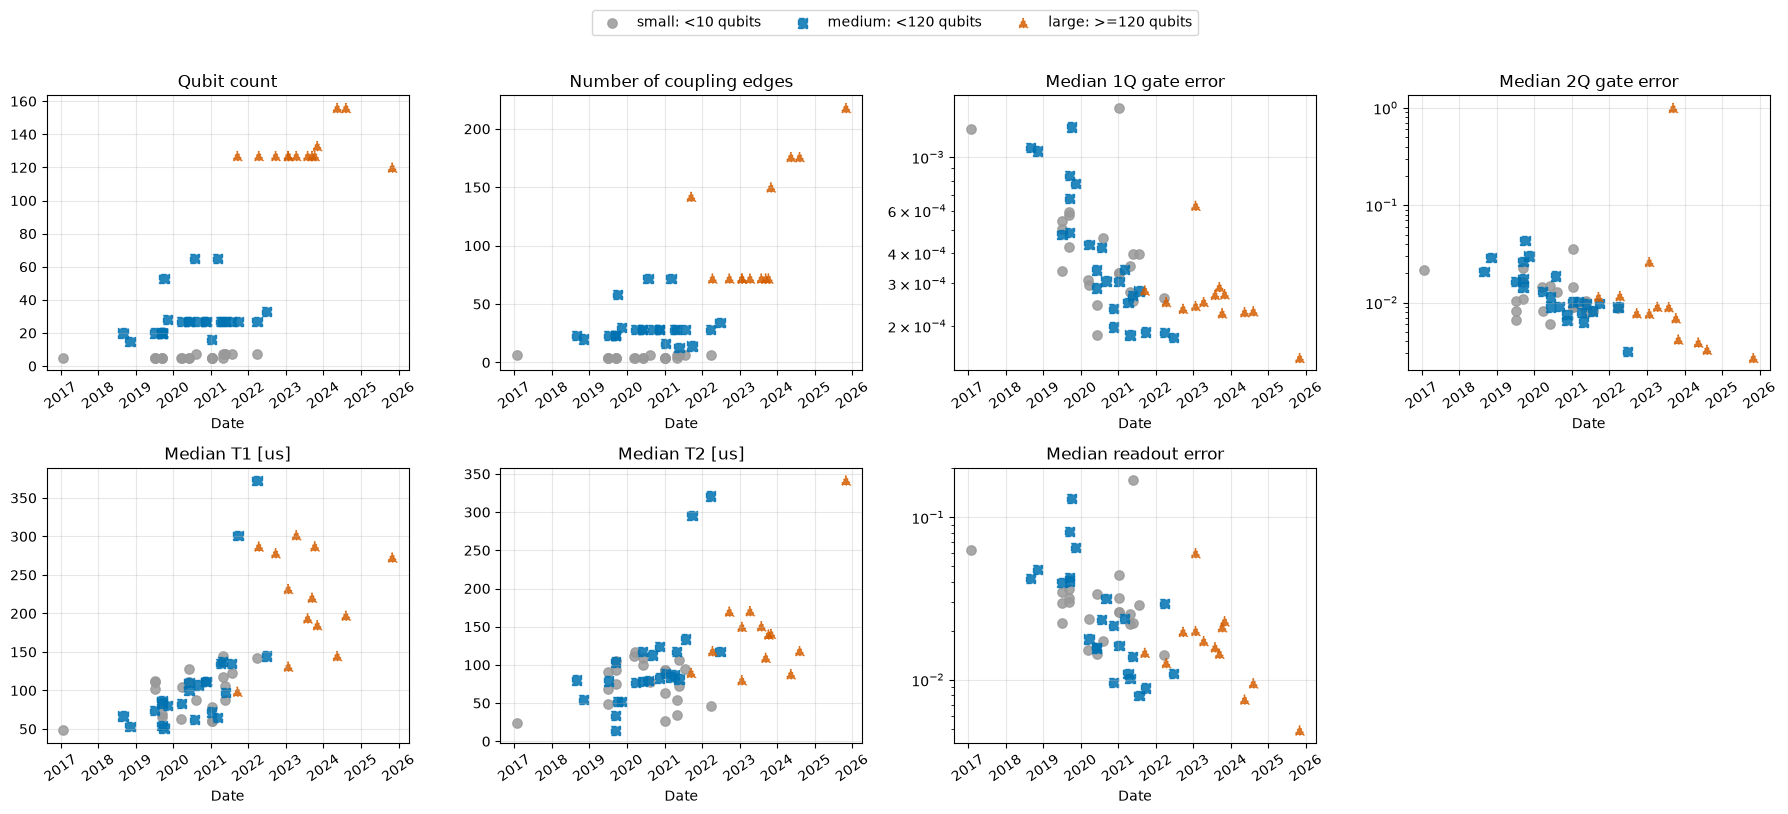

In [45]:
family_order = [
    "small: <10 qubits",
    "medium: <120 qubits",
    "large: >=120 qubits",
]

styles = {
    "small: <10 qubits":  {"color": "#999999", "marker": "o", "linestyle": "-"},
    "medium: <120 qubits": {"color": "#0072B2", "marker": "s", "linestyle": "--"},
    "large: >=120 qubits":  {"color": "#D55E00", "marker": "^", "linestyle": ":"},
}

metrics = [
    ("n_qubits", "Qubit count", False),
    ("n_coupling_edges", "Number of coupling edges", False),
    ("oneq_error_median", "Median 1Q gate error", True),
    ("twoq_error_median", "Median 2Q gate error", True),
    ("t1_median_us", "Median T1 [us]", False),
    ("t2_median_us", "Median T2 [us]", False),
    ("readout_error_median", "Median readout error", True),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (col, title, logy) in zip(axes, metrics):
    for family in family_order:
        sub = df[df["size_family"] == family].sort_values("date")
        ax.scatter(
            sub["date"],
            sub[col],
            label=family,
            s=45,
            alpha=0.85,
            **(styles[family])
        )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.grid(alpha=0.3)

    if logy:
        ax.set_yscale("log")

# Hide the last unused subplot
axes[len(metrics)].axis("off")

# Put legend only once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

# Rotate x tick labels
for ax in axes[:len(metrics)]:
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

The last plot summarizes the evolution of IBM Quantum hardware across several fake-provider backend snapshots.

Each point corresponds to one backend snapshot.
The x-axis shows the backend's `online_date`, and the color indicates the backend size family.
Across the snapshots, we can see a clear progression from small devices with only a few qubits and coupling edges to larger processors with more than 100 qubits and substantially richer connectivity.
At the same time, the calibration-related panels show the quality metrics that matter for circuit execution: one-qubit and two-qubit gate errors, readout errors, and the $T_1$ and $T_2$ coherence times.

Overall, the plot illustrates that IBM QPUs have not only scaled in size, but have also evolved in the hardware characteristics relevant to running quantum circuits.
Later backend snapshots generally provide larger qubit counts, denser coupling maps, lower gate and readout errors, and longer coherence times.

# Chapter 4 — Dynamic Circuit

Dynamic quantum circuits represent a fundamental evolution in the way we design and execute quantum algorithms. Unlike traditional quantum circuits, where all operations are predefined and measurements only occur at the end, dynamic circuits allow decisions to be made during execution based on intermediate measurement results.

In a traditional quantum circuit, the typical structure is:

<div align="center">

<b>Preparation</b> ──► <b>Quantum Operations</b> ──► <b>Final Measurement</b>

</div>


With dynamic circuits, you can do this:


<div align="center">

<table style="display:inline-table; border: 1px solid gray;">
<b>Preparation</b> ──►
<tr>
  <td align="center"><b>Operations</b></td>
  <td>──►</td>
  <td align="center"><b>Mid Measurement</b></td>
</tr>
<tr>
  <td colspan="3" align="center"><i>× p layers</i></td>
</tr>
</table>
──► <b>Final Measurement</b>

</div>

The power of dynamic circuits comes from using measurement results to control subsequent operations. This is known as "feedforward" or feedback.

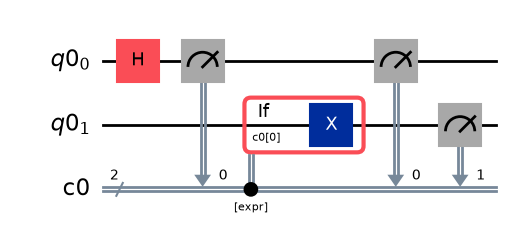

In [46]:
from qiskit.circuit.classical import expr
from qiskit import QuantumRegister,ClassicalRegister

qr = QuantumRegister(2)
cr = ClassicalRegister(2)
qc_dynamic = QuantumCircuit(qr,cr)

qc_dynamic.h(0)

qc_dynamic.measure(qr[0],cr[0])


# possible exercise indicate the condition of if_test
control = expr.lift(cr[0])

with qc_dynamic.if_test(control):
    qc_dynamic.x(1)

qc_dynamic.measure(qr[:2],cr)

qc_dynamic.draw("mpl")

To verify the result, the probability should be approximately equal between states `00` and `11`.

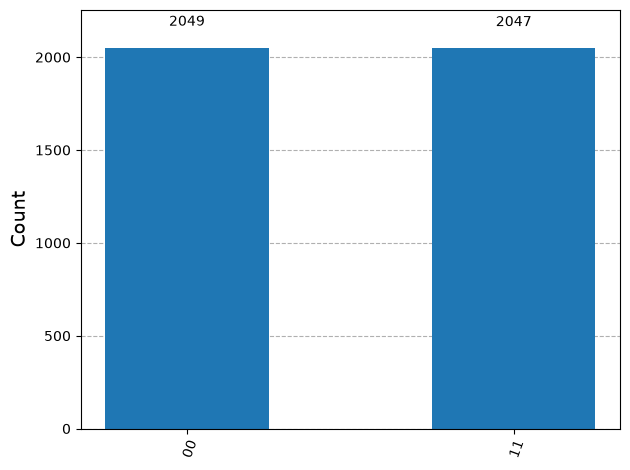

In [47]:
plot_histogram(transpile_and_run_counts(ideal_backend , qc_dynamic))


After measuring a qubit, you can reinitialize it to the |0⟩ state and reuse it. This is crucial when you have a limited number of physical qubits. For example:
`qc.reset(0)`

## 4.1 Dynamic GHZ 

In this section, like in Lab 1, we will be using the GHZ circuit by applying the principles of dynamic quantum circuits for its implementation. The goal is to build the same entangled state while reusing qubits mid-circuit — something that is only possible thanks to mid-circuit measurements and classical feedforward.

For this, we will follow the paper [Efficient Long-Range Entanglement Using Dynamic Circuits]( https://journals.aps.org/prxquantum/pdf/10.1103/PRXQuantum.5.030339), which derives the dynamic GHZ circuit through a series of circuit transformations. Here is an overview of each step:


- **(i)** We start by rearranging the original circuit: we push every second CNOT gate to the very right. This introduces the extra **pink CNOT gates** shown in the figure, and it is the key move that makes the rest of the simplification possible.

- **(ii)** After the rearrangement, some CNOT gates end up conditioned on a qubit that is still in state $|0\rangle$. Since a CNOT on $|0\rangle$ does nothing, we can safely omit those gates and simplify the circuit.

- **(iii)** Because every second qubit is now only involved at the very end of the circuit, there is a window where those qubits sit idle. We take advantage of that: we use them for the mid-circuit operation, then reset them back to $|0\rangle$ so they can be reused later.

- **(iv)** Here we apply a useful circuit identity: a Bell state followed by a CNOT gate is equivalent to two completely uncorrelated qubits, one in state $|{+}\rangle$ and one in state $|0\rangle$. This lets us break the circuit into smaller, more manageable pieces.

- **(v)** Next, we move the **pink CNOT gates** along the Bell states, sliding them up to the respective qubits above. This is valid because these gates commute with the other CNOT gates they pass through — the order does not affect the result.

- **(vi)** As we push the **pink CNOT gates** further to the left through the **purple CNOT gates**, new gates appear: the **orange CNOT gates**. These are the classically-controlled corrections that will implement the feedforward logic.

- **(vii)** At this point we apply the principle of **deferred measurement**: instead of keeping quantum information in a qubit, we measure it and use the classical outcome to control what happens next. This is exactly what makes the circuit dynamic.

- **(viii)** In the final step, we merge all the classically conditioned gates into a single operation. Since classical computation is extremely fast compared to quantum gate times, we represent it as a vertical line in the circuit diagram. The orange ⊕ symbols correspond to **XOR gates**. We also show the initial Bell states again using their circuit representation, so the full picture is clear.

In sections 4.1.1–4.1.7 below, we walk through each of these steps concretely on a 4-qubit example, building the circuit gate by gate.

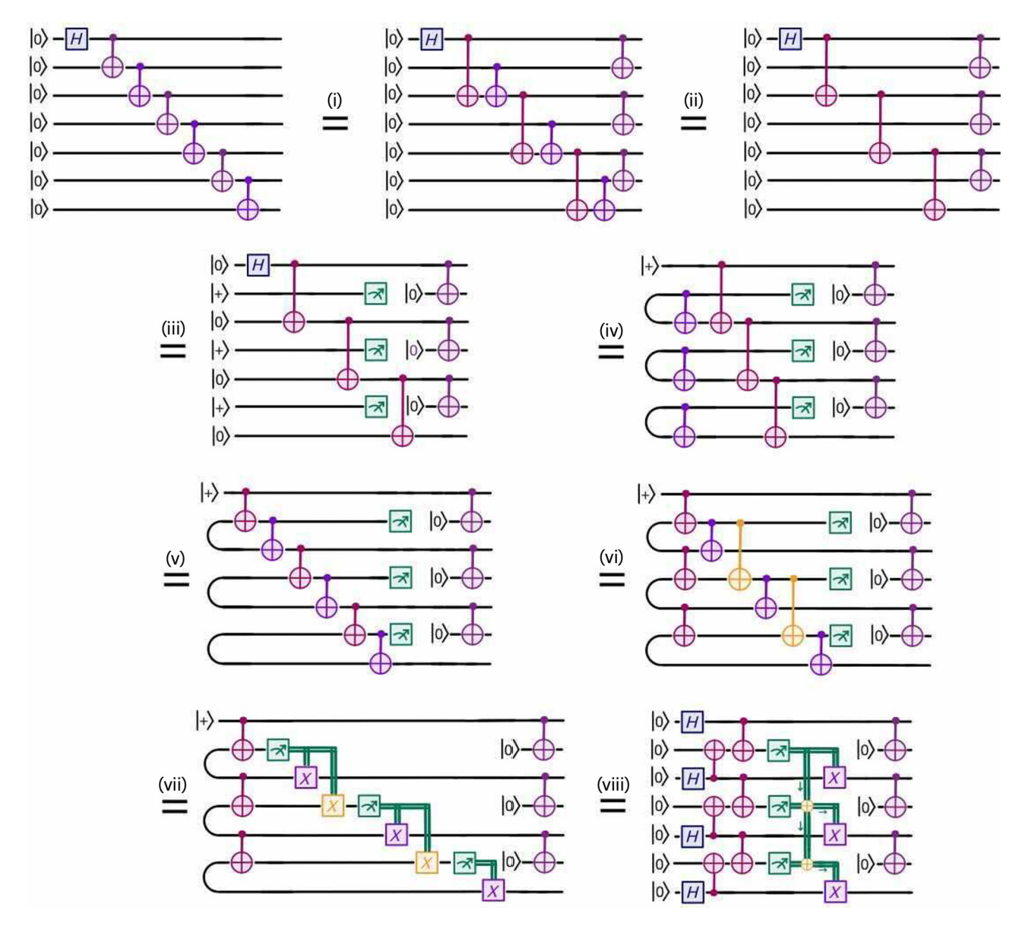




### 4.1.1 Step 1 - Add Hadamard gates to the data qubits
$H$ on $q_0$ and $q_2$ turns each qubit into $|+\rangle$ (two independent "coins" $a_0, a_2$):

$$|\psi_1\rangle = \tfrac12\big(|0000\rangle + |0001\rangle + |0100\rangle + |0101\rangle\big).$$

The four terms are just the four values of $(q_2,q_0)$. The bridge $q_1$ and edge $q_3$ are still $0$.

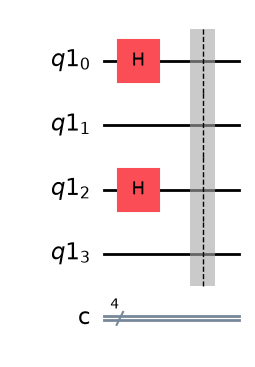

In [48]:
cr = ClassicalRegister(4,"c")
qr = QuantumRegister(4)
qc = QuantumCircuit(qr,cr)
qc.h(0) 
qc.h(2)  
qc.barrier()

qc.draw("mpl")

### 4.1.2 Step 2 - Add the First CNOT layer
Create a Bell pair on $(q_2,q_1)$, and now they are entangled, creating the bridge:
$$|\psi_2\rangle = \tfrac12\big(|0000\rangle + |0001\rangle + |0110\rangle + |0111\rangle\big).$$

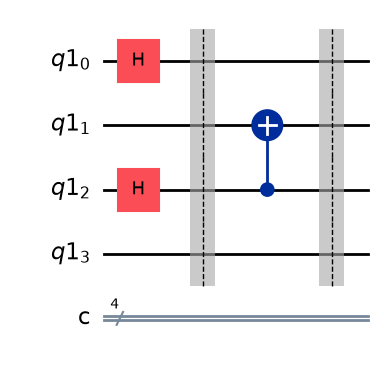

In [49]:
qc.cx(2, 1) 
qc.barrier()
qc.draw("mpl")

### 4.1.3 Step 3 - Add the Second CNOT layer
$CX(0,1)$ folds $q_0$ into the bridge, and $CX(2,3)$ entangles $q_2$ onto the edge qubit.

$$|\psi_3\rangle = \tfrac12\big(|0000\rangle + |0011\rangle + |1110\rangle + |1101\rangle\big).$$

In terms of the coins $a_0=q_0$ and $a_2=q_2$, the dependent qubits are now

$$q_1 = a_0 \oplus a_2, \qquad q_3 = a_2 .$$

The bridge $q_1$ holds the **parity** of its two neighbors, and measuring it reveals whether $a_0$ and $a_2$ agree.

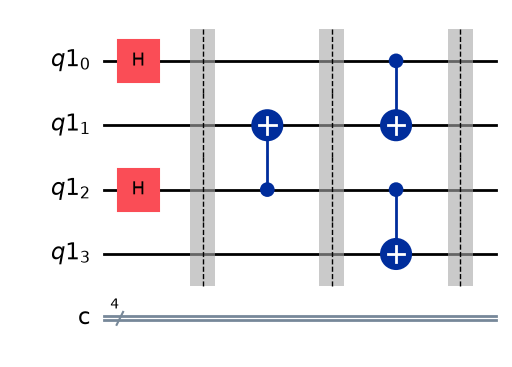

In [50]:
qc.cx(0, 1)
qc.cx(2, 3)   
qc.barrier()
qc.draw("mpl")

### 4.1.4 Step 4 - Measure the bridge and correct (feedforward)
Measuring the bridge $q_1$ gives a random bit $m_1 = a_0 \oplus a_2$ (it tells us whether the two coins agree). The two outcomes leave *different* states:

- $m_1 = 0:\quad \tfrac{1}{\sqrt2}\big(|0000\rangle + |1101\rangle\big)$
- $m_1 = 1:\quad \tfrac{1}{\sqrt2}\big(|0011\rangle + |1110\rangle\big)$

We reset $q_1$ to $|0\rangle$, then **only if $m_1 = 1$** flip the next pair $q_2, q_3$. After the correction, *both* outcomes give the same state:
$$|\psi_4\rangle = \tfrac{1}{\sqrt2}\big(|0000\rangle + |1101\rangle\big).$$
The random measurement result has been undone by the classically-controlled $X$. This is the heart of feedforward: the measurement is random, but the classically-controlled $X$ erases that randomness, leaving a deterministic 3-qubit GHZ on $q_0, q_2, q_3$ (with $q_1 = 0$).

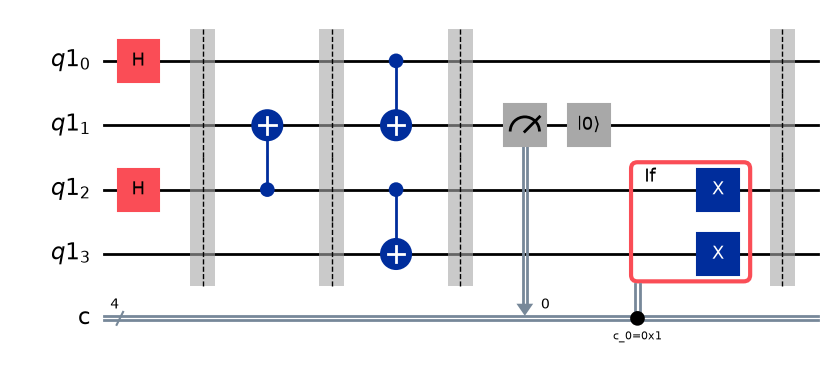

In [51]:
qc.measure(1, cr[0])             # measure the bridge q1
qc.reset(1)                      # reset it back to |0>
with qc.if_test((cr[0], 1)):     # if the outcome was 1...
    qc.x(2)                      # ...flip the next pair (q2, q3)
    qc.x(3)
qc.barrier()
qc.draw("mpl")

### 4.1.5 Step 5 - Measure and reset the edge qubit
For an even number of qubits, the edge qubit $q_3$ is a leftover partner of $q_2$, and the final layer will bring it back, so we measure and reset it. Measuring $q_3 = m_3$ and resetting gives:

- $m_3 = 0 \;\Rightarrow\; |0000\rangle$
- $m_3 = 1 \;\Rightarrow\; |0101\rangle$

Measuring $q_3$ pins down the shared value, leaving $q_0 = q_2 = m_3$.

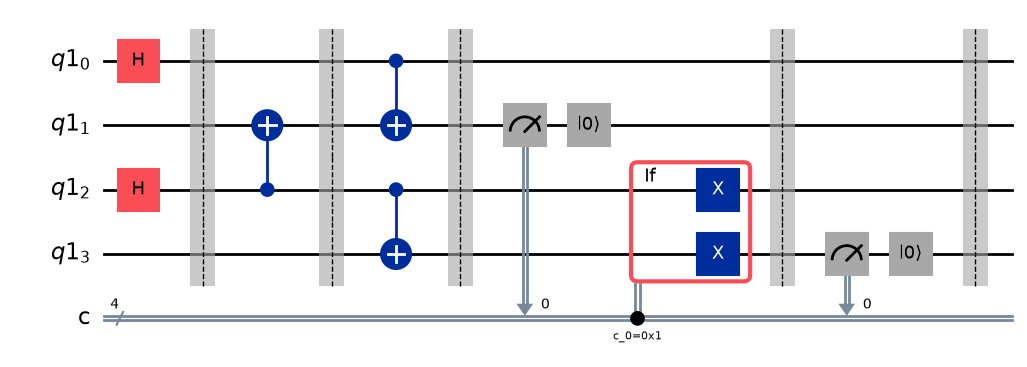

In [52]:
qc.measure(3, cr[0])   # measure the edge qubit q3 (reusing cr[0])
qc.reset(3)            # reset it back to |0>
qc.barrier()
qc.draw("mpl")


### 4.1.6 Step 6 - Final CNOT layer and readout
Now $q_0$ and $q_2$ hold the same definite value $m_3$, and $q_1, q_3$ are $0$. $CX(0,1)$ entangles $q_1$ and $q_0$ and $CX(2,3)$ entangles $q_3$ and $q_2$, so all four qubits end up equal:

- $m_3 = 0 \;\Rightarrow\; |0000\rangle$
- $m_3 = 1 \;\Rightarrow\; |1111\rangle$

Every run therefore reads out as all-zeros or all-ones: the GHZ signature.

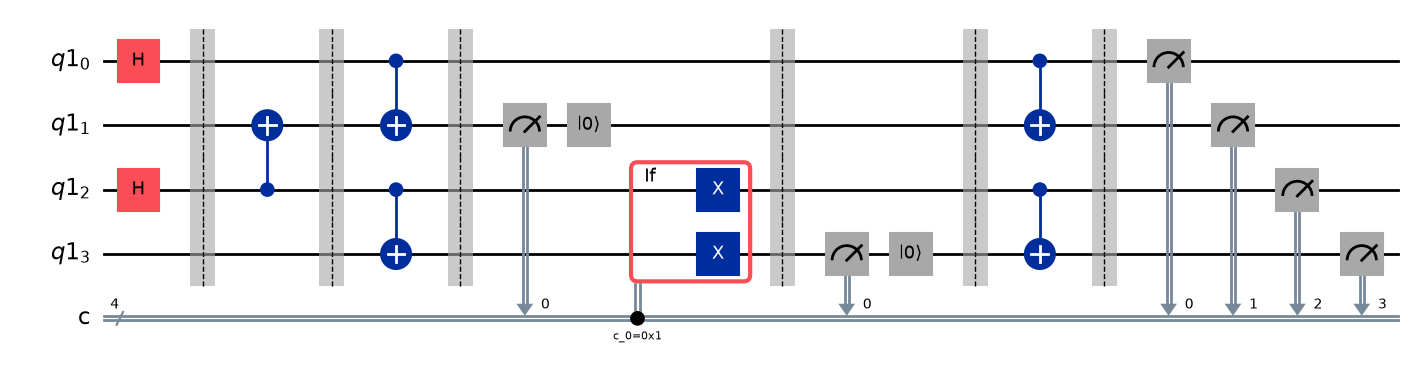

In [53]:
qc.cx(0, 1)
qc.cx(2, 3)
qc.barrier()
qc.measure(range(4), range(4))   # read out every qubit
qc.draw("mpl")

### 4.1.7 Run it
Sampling the circuit should give roughly a 50/50 split between $0000$ and $1111$, and nothing else.

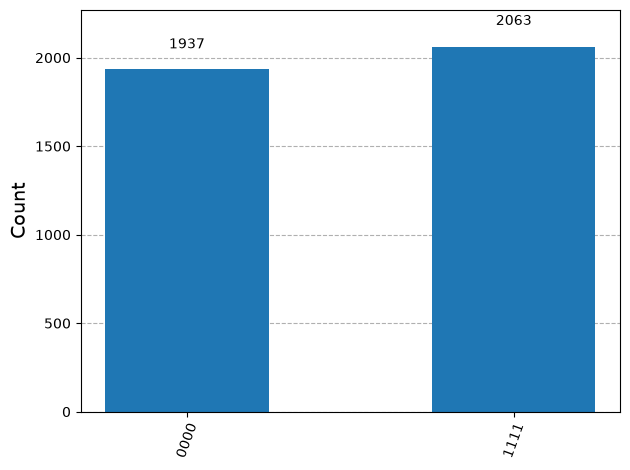

In [54]:
from qiskit_aer import AerSimulator

counts = AerSimulator().run(qc, shots=4000).result().get_counts()
plot_histogram(counts)

<div class="alert alert-block alert-success">
<b>Exercise 6.</b>
    <br>
  Create the function that builds a dynamic GHZ circuit in <b>create_dynamic_ghz_circuit</b> .<br>
</div>

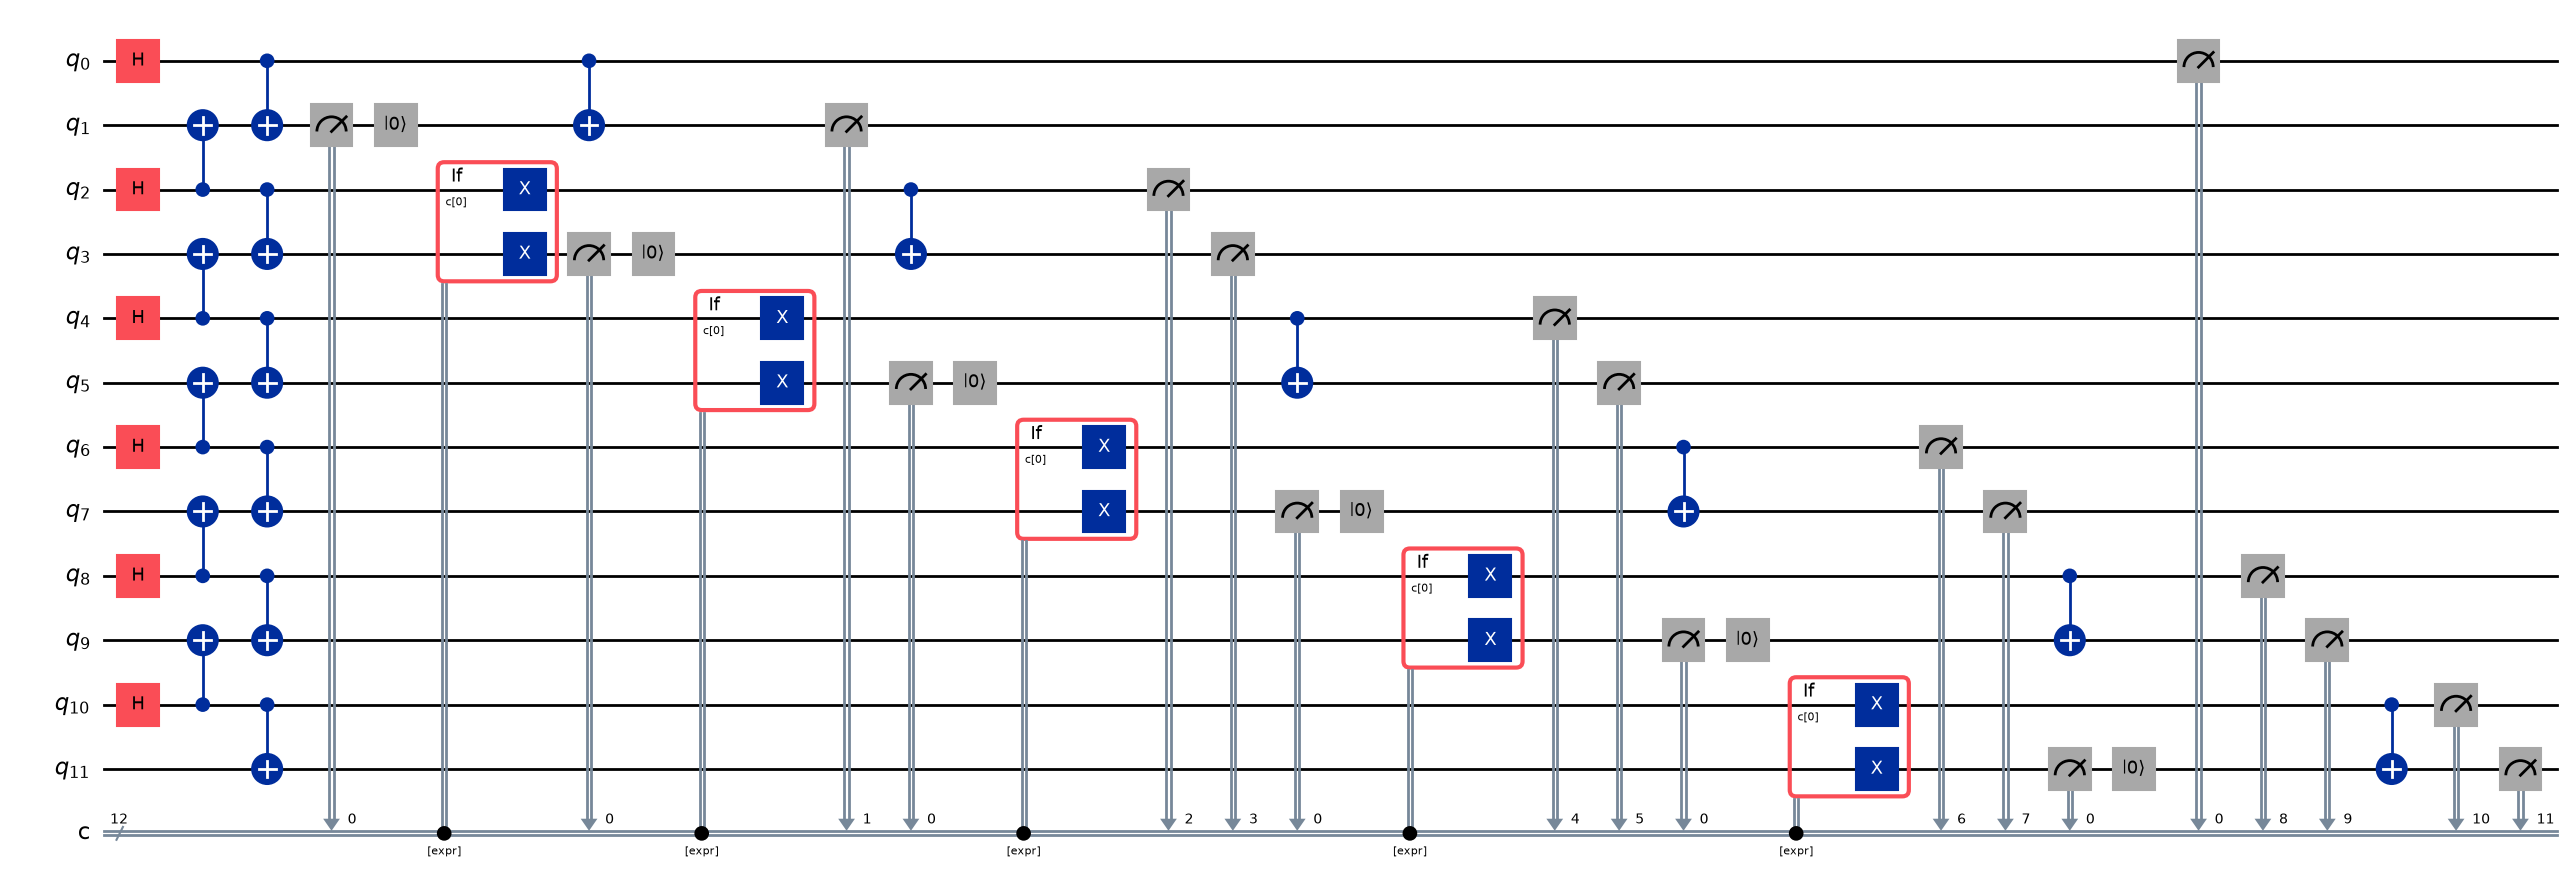

In [62]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr


def dynamic_ghz_circuit(num_qubits: int) -> QuantumCircuit:
    """
    Builds a dynamic GHZ circuit using mid-circuit measurements
    and classical feedforward operations.

    Args:
        num_qubits: Number of qubits (must be >= 2).

    Returns:
        A QuantumCircuit implementing the dynamic GHZ protocol.

    Raises:
        ValueError: If num_qubits < 2.
    """
    if not isinstance(num_qubits, int) or num_qubits < 2:
        raise ValueError("num_qubits must be an integer >= 2.")

    qr = QuantumRegister(num_qubits, name="q")
    cr = ClassicalRegister(num_qubits, name="c")
    qc = QuantumCircuit(qr, cr)

    _apply_initial_hadamards(qc, num_qubits)
    _apply_first_cnot_layer(qc, num_qubits)
    _apply_second_cnot_layer(qc, num_qubits)
    _apply_dynamic_section(qc, qr, cr, num_qubits)
    _apply_final_cnot_layer(qc, num_qubits)

    qc.measure(qr, cr)

    return qc


# --- Helper functions ---

def _apply_initial_hadamards(
    qc: QuantumCircuit,
    num_qubits: int,
) -> None:
    """
    Apply Hadamard gates to all even-indexed qubits.
    """
    for qubit in range(0, num_qubits, 2):
        qc.h(qubit)


def _apply_first_cnot_layer(
    qc: QuantumCircuit,
    num_qubits: int,
) -> None:
    """
    Apply CNOT gates: control=even, target=previous odd qubit.
    e.g. CX(2,1), CX(4,3), CX(6,5), ...
    """
    for control in range(2, num_qubits, 2):
        target = control - 1
        qc.cx(control, target)


def _apply_second_cnot_layer(
    qc: QuantumCircuit,
    num_qubits: int,
) -> None:
    """
    Apply CNOT gates: control=even, target=next odd qubit.
    e.g. CX(0,1), CX(2,3), CX(4,5), ...
    """
    for control in range(0, num_qubits - 1, 2):
        target = control + 1
        qc.cx(control, target)


def _apply_dynamic_section(
    qc: QuantumCircuit,
    qr: QuantumRegister,
    cr: ClassicalRegister,
    num_qubits: int,
) -> None:
    """
    Mid-circuit measurements with classical feedforward.
    Handles the main pairs and the final boundary qubit.
    """

    # Procesa los qubits impares interiores:
    # q1, q3, q5, ...
    for meas_qubit in range(1, num_qubits - 2, 2):

        # Corregir solamente el siguiente par.
        x_targets = [
            meas_qubit + 1,
            meas_qubit + 2,
        ]

        _measure_reset_and_correct(
            qc=qc,
            qr=qr,
            cr=cr,
            meas_qubit=meas_qubit,
            x_targets=x_targets,
        )

    # Tratamiento del último qubit impar.
    if num_qubits % 2 == 0:
        # n par: el último qubit no tiene un par completo
        # a su derecha. Solo se mide y resetea.
        _measure_and_reset_only(
            qc=qc,
            qr=qr,
            cr=cr,
            qubit=num_qubits - 1,
        )

    else:
        # n impar: el penúltimo qubit se mide y su
        # resultado corrige únicamente el último qubit.
        _measure_reset_and_correct(
            qc=qc,
            qr=qr,
            cr=cr,
            meas_qubit=num_qubits - 2,
            x_targets=[num_qubits - 1],
        )

def _apply_final_cnot_layer(
    qc: QuantumCircuit,
    num_qubits: int,
) -> None:
    """
    Apply final CNOT gates: control=even, target=next odd qubit.
    Same pattern as _apply_second_cnot_layer.
    """
    for control in range(0, num_qubits - 1, 2):
        target = control + 1
        qc.cx(control, target)


def _measure_reset_and_correct(
    qc: QuantumCircuit,
    qr: QuantumRegister,
    cr: ClassicalRegister,
    meas_qubit: int,
    x_targets: list[int],
) -> None:
    """
    Measure a qubit into cr[0], reset it, then conditionally
    apply X gates to the target qubits based on the measurement result.
    """
    # Medición a mitad del circuito.
    qc.measure(qr[meas_qubit], cr[0])

    # Reinicia el qubit medido al estado |0>.
    qc.reset(qr[meas_qubit])

    # Convierte el bit clásico en una condición booleana.
    control = expr.lift(cr[0])

    # Si la medición fue 1, corrige todos los qubits objetivo.
    with qc.if_test(control):
        for target in x_targets:
            qc.x(qr[target])


def _measure_and_reset_only(
    qc: QuantumCircuit,
    qr: QuantumRegister,
    cr: ClassicalRegister,
    qubit: int,
) -> None:
    """
    Measure a qubit into cr[0] and reset it,
    with no feedforward correction.
    """
    qc.measure(qr[qubit], cr[0])
    qc.reset(qr[qubit])


num_qubits = 12
qc_dynamic_ghz = dynamic_ghz_circuit(num_qubits)
qc_dynamic_ghz.draw("mpl", fold=-1)

To confirm the result, the probabilities of states `00...00` and `11...11` should be approximately equivalent

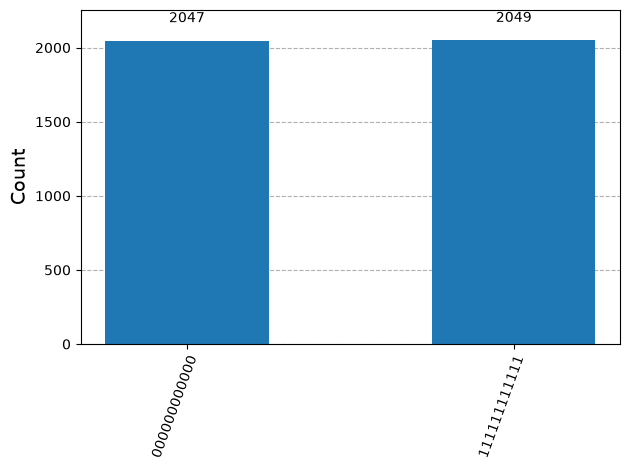

In [63]:
plot_histogram(transpile_and_run_counts(ideal_backend , qc_dynamic_ghz))

In [64]:
grade_lab2_ex6(build_circuit=dynamic_ghz_circuit)

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. You have correctly implemented the dynamic GHZ circuit.
You scored 1 on this exercise.


Now we will compare this implementation using different backends and assess whether using one backend or another is more convenient for a specific `initial_layout`

In [65]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

initial_layout_dynamic = [3,4,5,6,8,9,11,12,14,15,17,20]

pm_heron =  generate_preset_pass_manager(backend = backend_heron,initial_layout =initial_layout_dynamic,optimization_level=3)
pm_nightawk =  generate_preset_pass_manager(backend = backend_nighthawk,initial_layout =initial_layout_dynamic,optimization_level=3)


qc_dynamic_ghz_heron = pm_heron.run(qc_dynamic_ghz)
qc_dynamic_ghz_nighthawk = pm_nightawk.run(qc_dynamic_ghz)


<div class="alert alert-block alert-success">
<b>Exercise 7.</b>
    <br>
  Implement the <b>quantum_circuit_params</b> function to obtain the key characteristics needed to evaluate your quantum circuit.<br>
</div>

In [67]:
def quantum_circuit_params(circuit: QuantumCircuit) -> dict:
    """
    Extract key parameters from a QuantumCircuit.

    Args:
        circuit: The QuantumCircuit to analyze.

    Returns:
        A dictionary with the following keys:
            - "Number of qubits": total number of qubits in the circuit
            - "Depth": circuit depth (longest path of gates)
            - "2-qubit depth": depth counting only 2-qubit gates
            - "Gates": dictionary of gate names and their counts
            - "Multi-qubit gates": total number of multi-qubit gate operations
            - "Number of ancillas": number of ancilla qubits
    """
    # Profundidad total del circuito
    depth = circuit.depth()

    # Profundidad considerando únicamente operaciones de 2 qubits
    depth_2q = circuit.depth(
        lambda instruction: instruction.operation.num_qubits == 2
    )

    # Número total de operaciones que actúan sobre más de un qubit
    num_multi_qubit_ops = circuit.num_nonlocal_gates()

    # Cantidad de operaciones agrupadas por nombre
    ops = circuit.count_ops()

    # Número total de qubits
    num_qubits = circuit.num_qubits

    # Número de qubits auxiliares agregados durante la transpilación
    num_ancillas = circuit.num_ancillas

    return {
        "Number of qubits": num_qubits,
        "Depth": depth,
        "2-qubit depth": depth_2q,
        "Gates": ops,
        "Multi-qubit gates": num_multi_qubit_ops,
        "Number of ancillas": num_ancillas,
    }

quantum_circuit_params(qc_dynamic_ghz_nighthawk), quantum_circuit_params(qc_dynamic_ghz_heron)

({'Number of qubits': 120,
  'Depth': 71,
  '2-qubit depth': 24,
  'Gates': OrderedDict([('sx', 137),
               ('rz', 88),
               ('cz', 72),
               ('measure', 18),
               ('reset', 6),
               ('if_else', 5),
               ('x', 3)]),
  'Multi-qubit gates': 77,
  'Number of ancillas': 0},
 {'Number of qubits': 133,
  'Depth': 116,
  '2-qubit depth': 43,
  'Gates': OrderedDict([('sx', 178),
               ('cz', 92),
               ('rz', 91),
               ('measure', 18),
               ('reset', 6),
               ('if_else', 5),
               ('x', 3)]),
  'Multi-qubit gates': 97,
  'Number of ancillas': 0})

In [68]:
grade_lab2_ex7( quantum_circuit_params=quantum_circuit_params,build_circuit=dynamic_ghz_circuit) 

Grading your answer. Please wait...

Congratulations! 🎉 Your answer is correct. You have correctly implemented quantum_circuit_params. 

You scored 1 on this exercise.


To show these results that you constructed, they can be visualized below

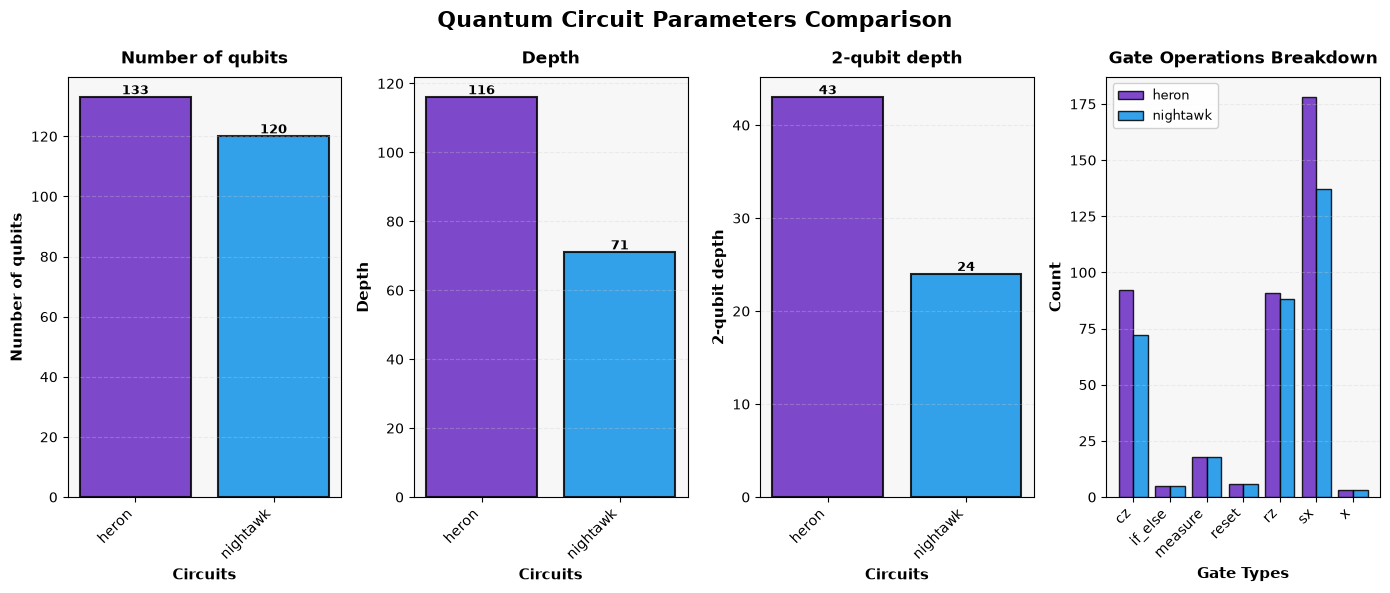

In [69]:

def plot_circuit_comparison(circuits_dict, figsize=(14, 6)):
    QISKIT_COLORS = [
        '#6929C4',  # Purple (primary Qiskit color)
        '#1192E8',  # Blue
    ]
    # Extract parameters for all circuits
    all_params = {}
    for name, circuit in circuits_dict.items():
        all_params[name] = quantum_circuit_params(circuit)
    
    # Prepare data for plotting
    circuit_names = list(all_params.keys())
    metrics = ["Number of qubits", "Depth", "2-qubit depth"]
    
    # Create subplots (1 row, 4 columns)
    fig, axes = plt.subplots(1, 4, figsize=figsize)
    fig.suptitle('Quantum Circuit Parameters Comparison', fontsize=16, fontweight='bold')
    
    # Use Qiskit colors
    colors = [QISKIT_COLORS[i % len(QISKIT_COLORS)] for i in range(len(circuit_names))]
    
    # Plot each metric in first 3 subplots
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        values = [all_params[name][metric] for name in circuit_names]
        
        bars = ax.bar(range(len(circuit_names)), values, color=colors, 
                      edgecolor='#000000', linewidth=1.5, alpha=0.85)
        
        ax.set_xlabel('Circuits', fontsize=11, fontweight='bold')
        ax.set_ylabel(metric, fontsize=11, fontweight='bold')
        ax.set_title(metric, fontsize=12, fontweight='bold', pad=10)
        ax.set_xticks(range(len(circuit_names)))
        ax.set_xticklabels(circuit_names, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linestyle='--', color='#CCCCCC')
        ax.set_facecolor('#F7F7F7')
        
        # Add value labels on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{value}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Gate operations comparison (last subplot)
    ax = axes[3]
    gate_types = set()
    for params in all_params.values():
        if isinstance(params["Gates"], dict):
            gate_types.update(params["Gates"].keys())
    
    if gate_types:
        gate_types = sorted(gate_types)
        x = np.arange(len(gate_types))
        width = 0.8 / len(circuit_names)
        
        for i, name in enumerate(circuit_names):
            gates = all_params[name]["Gates"]
            counts = [gates.get(gate, 0) for gate in gate_types]
            offset = (i - len(circuit_names)/2) * width + width/2
            ax.bar(x + offset, counts, width, label=name, 
                   color=colors[i], edgecolor='#000000', linewidth=1, alpha=0.85)
        
        ax.set_xlabel('Gate Types', fontsize=11, fontweight='bold')
        ax.set_ylabel('Count', fontsize=11, fontweight='bold')
        ax.set_title('Gate Operations Breakdown', fontsize=12, fontweight='bold', pad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(gate_types, rotation=45, ha='right')
        ax.legend(fontsize=9, framealpha=0.9)
        ax.grid(axis='y', alpha=0.3, linestyle='--', color='#CCCCCC')
        ax.set_facecolor('#F7F7F7')
    else:
        ax.text(0.5, 0.5, 'No gate data available', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.axis('off')
    
    plt.tight_layout()
    return fig

circuits = {
        "heron": qc_dynamic_ghz_heron,
        "nightawk": qc_dynamic_ghz_nighthawk
    }

fig = plot_circuit_comparison(circuits)
plt.show()


Congratulations! This concludes Lab 2, where you learned the essential tools to understand noise composition, mitigate it through hardware-level physical considerations, and optimize quantum circuits using dynamic circuits. The tools covered here will prove valuable when working with quantum hardware, analyzing different architectures, and identifying the benefits of implementing your algorithm on real hardware.

In [70]:
check_progress("lab2")

Fetching your progress. Please wait...

📊 Your progress

Lab "lab2" — 7/7 passed, score 8.0
  ✅ ex1 — score 2.0
  ✅ ex2 — score 1.0
  ✅ ex3 — score 1.0
  ✅ ex4 — score 1.0
  ✅ ex5 — score 1.0
  ✅ ex6 — score 1.0
  ✅ ex7 — score 1.0


# Bonus (This is not mandatory)

**Only run this section if you know you know that you have enough time on the cloud left.** (For example, after you have done all the mandatory exercises in all labs.)


In the previous sections we ran the dynamic GHZ circuit on simulators and fake backends.
In this bonus section we submit it to **real IBM Quantum hardware** using `qiskit-ibm-runtime`.

Running on real hardware introduces everything we studied:
- The gate errors, readout noise, decoherence, and hardware connectivity constraints.
- The dynamic circuit variant is especially interesting here because mid-circuit measurements and feedforward classical control are only recently supported on IBM Quantum devices, making this a genuine test of modern hardware capabilities.


#### Authenticate and Select a Backend

To run on real hardware, you need an [IBM Quantum account](https://quantum.cloud.ibm.com/).
Save your API token once with `QiskitRuntimeService.save_account(...)` and it will be
reused automatically in future sessions.

**Dynamic circuit support:** not all IBM Quantum backends support mid-circuit measurements and classical feedforward. Look for the `dynamic_reprate_enabled` flag or check the backend's `operations` list for `if_else`. Eagle/Heron devices generally support this feature. If your preferred backend doesn't support it, the transpiler will raise an error.

In [71]:
from qiskit_ibm_runtime import QiskitRuntimeService

# -------------------------------------------------------------------
# 1a. Save credentials once (run only once, then comment out):
# QiskitRuntimeService.save_account(
#     channel="ibm_cloud",
#     token="<YOUR_IBM_QUANTUM_API_TOKEN>",
#     overwrite=True,
# )
# -------------------------------------------------------------------

# 1b. Load saved credentials and connect to the IBM Cloud channel.
service = QiskitRuntimeService(channel="ibm_cloud")

# 1c. Pick the least-busy backend that supports dynamic circuits
#     and has enough qubits for our 12-qubit GHZ experiment.
backend_hw = service.least_busy(
    operational=True,
    min_num_qubits=12,
    dynamic_circuits=True,       # require dynamic-circuit support
)

print(f"Selected backend : {backend_hw.name}")
print(f"Number of qubits : {backend_hw.num_qubits}")
print(f"Status           : {backend_hw.status().status_msg}")
print(f"Queue depth      : {backend_hw.status().pending_jobs} jobs pending")

Selected backend : ibm_fez
Number of qubits : 156
Status           : active
Queue depth      : 0 jobs pending


#### Inspect Hardware Properties

Before submitting, it is good practice to look at the backend properties we studied in Chapter 1: gate errors, readout errors, and coherence times.
This helps us choose a good initial layout and set realistic expectations.

In [72]:
plot_gate_map(backend_hw)

MissingOptionalLibraryError: "The 'Graphviz' library is required to use 'plot_coupling_map'.  To install, follow the instructions at https://graphviz.org/download/. Qiskit needs the Graphviz binaries, which the 'graphviz' package on pip does not install. You must install the actual Graphviz software."

#### Choose an Initial Layout

We use the same 12-qubit dynamic GHZ circuit built in Chapter 4.
The `initial_layout_dynamic` list maps our 12 logical qubits to physical qubits that have good connectivity and low error rates on the chosen backend.

Adjust the list below if your backend has a different topology or if the error table above suggests better qubit candidates.

In [ ]:
#TODO: Change the code below as needed to adapt to the backend

# Reuse the 12-qubit dynamic GHZ circuit from Chapter 4.
num_qubits_bonus = 12
qc_bonus = dynamic_ghz_circuit(num_qubits_bonus)

# Choose physical qubits with good properties on the selected backend.
# This layout works well for Heron and similar heavy-hex devices.
# Modify it based on the gate-map and error table above for other backends.
initial_layout_hw = [3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 17, 20]

# Build and run the preset pass manager at optimization level 1.
# We use level 1 rather than 3 to keep transpilation deterministic and
# to avoid the pass manager reordering mid-circuit measurements.
pm_hw = generate_preset_pass_manager(
    backend=backend_hw,
    initial_layout=initial_layout_hw,
    optimization_level=1,
)

qc_bonus_transpiled = pm_hw.run(qc_bonus)

print("Transpiled circuit parameters:")
params = quantum_circuit_params(qc_bonus_transpiled)
for k, v in params.items():
    if k != 'Gates':
        print(f"  {k}: {v}")
print(f"  Gate breakdown: {dict(params['Gates'])}")

#### Submit to Hardware 

`SamplerV2` is the recommended way to run circuits on IBM Quantum hardware through the Qiskit Runtime service. It handles session management, job queuing, and result packaging for us.

In [ ]:
shots_hw = 4096

sampler_hw = Sampler(mode=backend_hw)
job_hw = sampler_hw.run([qc_bonus_transpiled], shots=shots_hw)

print(f"Job ID   : {job_hw.job_id()}")
print(f"Status   : {job_hw.status()}")
print("Waiting for the job to complete (this may take several minutes)...")

In [ ]:
# Block until results are available.
# On a busy backend this can take anywhere from seconds to tens of minutes.
result_hw = job_hw.result()

# Extract counts from the first (and only) pub result.
cr_keys = list(result_hw[0].data.keys())
counts_hw = result_hw[0].data[cr_keys[0]].get_counts()

print(f"Total shots : {sum(counts_hw.values())}")
print("Top-10 outcomes:")
for bitstring, count in sorted(counts_hw.items(), key=lambda x: -x[1])[:10]:
    print(f"  {bitstring}: {count}")

#### Compare Hardware vs. Ideal Simulator

We now run the *same* transpiled circuit on the ideal `AerSimulator` and plot both distributions side by side. This gives us a direct visual measure of how much the hardware deviates from the ideal GHZ state.

In [ ]:
def top_n(counts, n=10):
    """Return a new counts dict with only the top-n bitstrings by count."""
    return dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:n])

# Run the transpiled circuit on the ideal AerSimulator for reference.
ideal_backend_bonus = AerSimulator()
counts_ideal_bonus = run_counts(ideal_backend_bonus, qc_bonus_transpiled, shots=shots_hw)

# Keep only top 10 from each distribution
top_ideal = top_n(counts_ideal_bonus, 10)
top_hw    = top_n(counts_hw, 10)

# Side-by-side histogram
plot_histogram(
    [top_ideal, top_hw],
    legend=["Ideal simulator", f"Hardware ({backend_hw.name})"],
    figsize=(14, 5),
    title="Dynamic GHZ (12 qubits): Ideal vs. Real Hardware (Top 10)",
)

# Wrap-up

In this bonus section you:

- Authenticated to IBM Quantum and selected a real backend that supports dynamic circuits.
- Inspected hardware properties (gate errors, readout errors, coherence times)  to guide qubit selection.
- Transpiled the 12-qubit dynamic GHZ circuit for that backend.

The gap between the fake-backend prediction and the real-hardware result reflects noise sources that the calibrated noise model does not fully capture: crosstalk, leakage, drift, and the overhead introduced by classical feedforward.
Narrowing that gap is one of the central goals of quantum error mitigation research.

# Additional information

**Created by:** Alberto Maldonado Romo & Gwonhak Lee

**Version:** 1.0.0